In [1]:
import pysam
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import pickle
import numpy as np
import pandas as pd
import re
import seaborn as sns
import csv

In [2]:
print(pd.__version__)

2.2.3


In [3]:
#check read depth results
def checkReadDepth(samples):
    sampleResList = []
    for sample in samples:
        file = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/readDepth/{sample}_read_depth.txt'
        if os.path.exists(file):
            if os.stat(file).st_size == 0:
                print(f'{sample},File is empty')
            else:
                sampleResList.append(sample)
        else:
            print(f'{sample},File no exists')
    return sampleResList

In [4]:
def checkData(path,scriptPath):
    samples = os.listdir(path)
    sampleWithFusions = 0
    error_list = []
    step2 = []
    for sample in samples:
        if 'Sample_' in sample:
            #check if error files exists
            error = f'{scriptPath}/{sample}/{sample}_searcHPV.err'
            if os.path.exists(error):
                with open(error) as errorFile:
                    if 'Error' in errorFile.read() or 'error' in errorFile.read():
                        error_list.append(sample)

            else:
                print(f'no error file,{sample}')


            #check if step2 files exists
            step2Path = f"{path}/{sample}/call_fusion/"
            hasFile = False
            for each in os.listdir(step2Path):
                if "all.filtered.clustered.result" in each:
                    hasFile = True
            if hasFile == False:
                print(sample,"no step2 results")
    return step2,error_list
                
        
  

In [5]:
!ls /home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res/Sample_2655-CB-28/call_fusion

gi_333031_lcl_HPV16REF_1_.all.clustered.result
gi_333031_lcl_HPV16REF_1_.all.filtered.clustered.result
gi_333031_lcl_HPV16REF_1_.all.result
gi_333031_lcl_HPV16REF_1_.genome_fusion.sort.txt
gi_333031_lcl_HPV16REF_1_.genome_fusion.txt


In [6]:
#check read data
path1 = '/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res'
sampleList = os.listdir(path1)
sampleResList = checkReadDepth(sampleList)
#check result
step2List = []
scriptPath1 = '/home/wenjingu/remillsscr/HPV_fusion/targeted_exom/our_pip/newVersion/allSample/'
step2,error = checkData(path1,scriptPath1)
step2List += step2

In [7]:
#load bgCov
#distribution plot
readDepth = "/home/wenjingu/remillsscr/HPV_fusion/targeted_exom/our_pip/newVersion/normReadDepth/readDepthAll.txt"
readNum = "/home/wenjingu/remillsscr/HPV_fusion/targeted_exom/our_pip/newVersion/normReadDepth/readNumAll.txt"
depthDic = {}
geneLengthDic = {}
geneNumberDic = {}
with open(readDepth) as input1:
    rows = input1.read().rstrip().split('\n')
    for row in rows:
        gene = row.split('\t')[0]
        depthList = row.split('\t')[1].split(',')
        depthDic[gene] = depthList
        lengthList = row.split('\t')[2].split(',')
        geneLengthDic[gene] = lengthList
with open(readNum) as input2:
    rows = input2.read().rstrip().split('\n')
    for row in rows:
        gene = row.split('\t')[0]
        readNumList = row.split('\t')[1]
        geneNumberDic[gene] = readNumList

In [8]:
MAP2K4 = {}
for gene in depthDic:
    if int(geneLengthDic[gene][2]) == 0 or int(geneNumberDic[gene]) == 0:
        print(gene,int(depthDic[gene][2]),int(geneLengthDic[gene][2]),int(geneNumberDic[gene]))
    else:
        MAP2K4['Sample_'+gene] = int(depthDic[gene][2])/int(geneLengthDic[gene][2])

In [9]:
MAP2K4['Sample_81279']

326.7625

In [10]:
#read final searcHPV data
def readData(path):
    samples = os.listdir(path)
    selectedNewContig = {}
    sampleWithFusions = 0
    for sample in samples:
        if 'Sample_' in sample:
            resPath = f"{path}/{sample}/call_fusion_virus/HPVfusionPointContig.txt"
            resdicPath = f"{path}/{sample}/call_fusion_virus/filteredSelectedContig.pickle"
            #print(resPath)
            if not os.path.isfile(resdicPath):
                print(sample)
            else:
                with open(resdicPath,'rb') as resDicFile:
                    resDic = pickle.load(resDicFile)

                    selectedNewContig[sample] = resDic
                sampleWithFusions += 1
    return selectedNewContig

In [11]:
path1 = '/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res/'
batch1 = readData(path1)

In [12]:
def add_batch(all_dic,batch):
    for key,value in batch.items():
        all_dic[key] = value
    return all_dic

In [13]:
all_dic = {}
add_dic = add_batch(all_dic,batch1)

In [14]:
all_dic.keys()

dict_keys(['Sample_2655-CB-28', 'Sample_83092', 'Sample_126519', 'Sample_126437', 'Sample_83075', 'Sample_83089', 'Sample_103169', 'Sample_2655-CB-4', 'Sample_6670-CB-13', 'Sample_83091', 'Sample_2655-CB-78', 'Sample_2920-CB-37', 'Sample_152-CB-72', 'Sample_2789-CB-28', 'Sample_126501', 'Sample_83096', 'Sample_97009', 'Sample_2655-CB-69', 'Sample_2789-CB-74', 'Sample_96919', 'Sample_2920-CB-8', 'Sample_126516', 'Sample_6670-CB-21', 'Sample_83095', 'Sample_96940', 'Sample_109374', 'Sample_103134', 'Sample_6670-CB-27', 'Sample_2920-CB-49', 'Sample_6670-CB-66', 'Sample_83084', 'Sample_83073', 'Sample_2655-CB-16', 'Sample_2655-CB-59', 'Sample_2655-CB-45', 'Sample_2920-CB-42', 'Sample_96959', 'Sample_126529', 'Sample_126526', 'Sample_2789-CB-20', 'Sample_115297', 'Sample_115295', 'Sample_126491', 'Sample_109330', 'Sample_109313', 'Sample_88113', 'Sample_2920-CB-5', 'Sample_83039', 'Sample_2789-CB-36', 'Sample_96965', 'Sample_103159', 'Sample_115309', 'Sample_126479', 'Sample_152-CB-43', 'Sa

In [15]:
!ls ../Figure1/Sup_1_QC_nanopore_samples.xlsx

../Figure1/Sup_1_QC_nanopore_samples.xlsx


In [16]:
!pwd

/nfs/turbo/remillsscr/wenjingu/HPV_fusion/targeted_exom/our_pip/newVersion/analysis/script_for_big_paper/Figure2


In [17]:
ann = '../Figure1/Sup_1_QC_nanopore_samples.xlsx'
annDf = pd.read_excel(ann,sheet_name='QC_nanopore_hg38')
patientResDic = {}
not_in_list = []
sampleInvolveList = []
for sample in all_dic:
    is_tumor = False
    not_in = True
    i = 0
    #print(sample)
    for seqID in annDf['TCS ID']:
        if sample.replace('Sample_','') == str(seqID):
            
            is_tumor = True
            not_in = False
            sampleInvolveList.append(sample)
            if sample not in patientResDic:
                patientResDic[str(seqID)] = []
            for site in all_dic[sample]:
                patientResDic[str(seqID)].append(site)
        i += 1
    
    if not_in:
        not_in_list.append(sample)

In [18]:
sampleInvolveList

['Sample_6670-CB-87',
 'Sample_6670-CB-88',
 'Sample_2655-CB-91',
 'Sample_2655-CB-89',
 'Sample_2655-CB-86',
 'Sample_2655-CB-90',
 'Sample_2655-CB-84',
 'Sample_6670-CB-90',
 'Sample_2655-CB-88',
 'Sample_2655-CB-92',
 'Sample_2655-CB-93',
 'Sample_6670-CB-92',
 'Sample_6670-CB-86',
 'Sample_81279',
 'Sample_152-CB-96',
 'Sample_2655-CB-85',
 'Sample_6670-CB-93',
 'Sample_6670-CB-91']

In [19]:
len(sampleInvolveList)

18

In [20]:
#write sample list to file
sampleListFile = 'sampleList_LR_04222025.txt'
with open(sampleListFile,'w') as output:
    for sample in sampleInvolveList:
        output.write(f'{sample}\n')

In [21]:
#extract Integrations for these samples
path = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/allSample.04.23.25/'
if not os.path.exists(path):
    os.mkdir(path)
with open("sampleList_LR_04222025.txt") as inputFile:
    with open(path + 'TCSIntegrationList_LR.txt','w') as outputFile:
        samples = inputFile.read().rstrip().split('\n')
        for sample in samples:
            if all_dic[sample] != {}:
                for ins in all_dic[sample]:
                    chro = ins.split('.')[0]
                    site = ins.split('.')[1]
                    outputFile.write(f'{sample},{chro},{site}\n')

In [22]:
# #change to bed format
# path = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/allSample.01.25.23/TCSIntegrationList.bed'
# with open("sampleList01_25_23.txt") as inputFile:
#     with open(path,'w') as outputFile:
#         samples = inputFile.read().rstrip().split('\n')
#         for sample in samples:
#             if all_dic[sample] != {}:
#                 for ins in all_dic[sample]:
#                     chro = ins.split('.')[0]
#                     site = ins.split('.')[1]
#                     outputFile.write(f'chr{chro}\t{site}\t{site}\t{sample}\n')
    
    
    
    

In [23]:
patientResDic

{'6670-CB-87': ['1.182207603'],
 '6670-CB-88': [],
 '2655-CB-91': ['9.97813335',
  '9.97908821',
  '2.32916236',
  '6.79484344',
  '11.131789342',
  '8.46619611',
  '9.26645008',
  '9.97901339',
  '9.97902954',
  '3.82226566',
  '9.99956760',
  '2.151136063',
  '9.97860564',
  '9.97833766',
  '7.83120494',
  '3.141401612',
  '18.22565190',
  '9.97914603',
  '12.66057682',
  '3.93470710',
  '3.81785783',
  '9.97857784',
  '9.97952091',
  '4.103351588',
  '9.97814224',
  '9.97940224',
  '9.97869989',
  '9.97942608',
  '3.81992132',
  '9.116921587',
  '3.93470597',
  '9.97942781'],
 '2655-CB-89': ['17.38267232',
  '3.51533589',
  '3.51527285',
  '1.215747897',
  '3.51502997',
  '15.31335022',
  '17.38269138',
  '12.66057678',
  '15.31335186',
  '11.70269302',
  '2.100978863',
  '3.51543376',
  '3.51512714',
  '10.43440220',
  'X.33461718',
  '11.70283619',
  '17.38323632',
  '2.32916253',
  '3.51503437',
  '9.105366950'],
 '2655-CB-86': ['3.189886392'],
 '2655-CB-90': ['3.93470662',
  '2.

In [24]:
#cluster site within 500kb
clusteredSite = {}
clusteredSiteRes = {}
for sample in patientResDic:
    #cluster site within 500kb
    resList = patientResDic[sample]
    clusteredSite[sample] = {}
    clusteredSiteRes[sample] = {}
    if resList != []:
        for each in resList:
            chro1 = each.split('.')[0]
            ins1 = int(each.split('.')[1])
            
            if chro1 in clusteredSite[sample]:
                clusteredSite[sample][chro1].append(ins1)
            else:
                clusteredSite[sample][chro1] = [ins1]
        for eachChro in clusteredSite[sample]:
            #print(clusteredSite[sample][eachChro])
            a = np.array(clusteredSite[sample][eachChro])
            #print(a)
            a = sorted(clusteredSite[sample][eachChro])
            deltaList = [0]
            for i in range(len(a)-1):
                deltaList.append(abs(a[i+1]-a[i]))
            cutList = []
            for i in range(len(deltaList)):
                if deltaList[i] > 500000:
                    cutList.append(i)
            #print(cutList)
            if cutList != []:
                clusteredSiteRes[sample][eachChro] = [a[0:cutList[0]],a[cutList[-1]:]]#add the first and last slots
                for i in range(len(cutList)-1):
                    clusteredSiteRes[sample][eachChro].append(a[cutList[i]:cutList[i+1]])
            else:
                clusteredSiteRes[sample][eachChro] = [a]
    

In [25]:
clusteredSiteRes

{'6670-CB-87': {'1': [[182207603]]},
 '6670-CB-88': {},
 '2655-CB-91': {'9': [[26645008],
   [116921587],
   [97813335,
    97814224,
    97833766,
    97857784,
    97860564,
    97869989,
    97901339,
    97902954,
    97908821,
    97914603,
    97940224,
    97942608,
    97942781,
    97952091],
   [99956760]],
  '2': [[32916236], [151136063]],
  '6': [[79484344]],
  '11': [[131789342]],
  '8': [[46619611]],
  '3': [[81785783, 81992132, 82226566], [141401612], [93470597, 93470710]],
  '7': [[83120494]],
  '18': [[22565190]],
  '12': [[66057682]],
  '4': [[103351588]]},
 '2655-CB-89': {'17': [[38267232, 38269138, 38323632]],
  '3': [[51502997, 51503437, 51512714, 51527285, 51533589, 51543376]],
  '1': [[215747897]],
  '15': [[31335022, 31335186]],
  '12': [[66057678]],
  '11': [[70269302, 70283619]],
  '2': [[32916253], [100978863]],
  '10': [[43440220]],
  'X': [[33461718]],
  '9': [[105366950]]},
 '2655-CB-86': {'3': [[189886392]]},
 '2655-CB-90': {'3': [[81785783, 81992132, 822

In [26]:
len(clusteredSiteRes)

18

In [27]:
#plots
numCluster = 0
numSample = 0
lenClusterList = []
sampleGreat2 = []
numCluster = 0
for sample in clusteredSiteRes:
    hasCluster = False
    for chro in clusteredSiteRes[sample]:
        for cluster in clusteredSiteRes[sample][chro]:
            if len(cluster) > 0:
                numCluster += 1
                hasCluster = True
                lenClusterList.append(len(cluster))
            if len(cluster) > 1:
                sampleGreat2.append(sample)
                

    if hasCluster == True:
        numSample += 1


In [28]:
numCluster

174

In [29]:
clusteredSiteRes

{'6670-CB-87': {'1': [[182207603]]},
 '6670-CB-88': {},
 '2655-CB-91': {'9': [[26645008],
   [116921587],
   [97813335,
    97814224,
    97833766,
    97857784,
    97860564,
    97869989,
    97901339,
    97902954,
    97908821,
    97914603,
    97940224,
    97942608,
    97942781,
    97952091],
   [99956760]],
  '2': [[32916236], [151136063]],
  '6': [[79484344]],
  '11': [[131789342]],
  '8': [[46619611]],
  '3': [[81785783, 81992132, 82226566], [141401612], [93470597, 93470710]],
  '7': [[83120494]],
  '18': [[22565190]],
  '12': [[66057682]],
  '4': [[103351588]]},
 '2655-CB-89': {'17': [[38267232, 38269138, 38323632]],
  '3': [[51502997, 51503437, 51512714, 51527285, 51533589, 51543376]],
  '1': [[215747897]],
  '15': [[31335022, 31335186]],
  '12': [[66057678]],
  '11': [[70269302, 70283619]],
  '2': [[32916253], [100978863]],
  '10': [[43440220]],
  'X': [[33461718]],
  '9': [[105366950]]},
 '2655-CB-86': {'3': [[189886392]]},
 '2655-CB-90': {'3': [[81785783, 81992132, 822

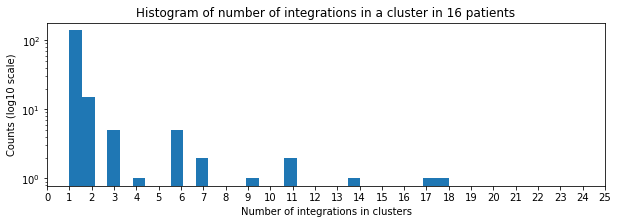

In [30]:
#histogram of number of integrations in clusters in all patients 
#cluster is defined for each sample seperately
plt.figure(figsize = [10,3])
plt.hist([x for x in lenClusterList],bins = 30)
plt.xticks(range(0,26,1))
plt.yscale('log', nonpositive='clip')
plt.xlabel('Number of integrations in clusters')
plt.ylabel('Counts (log10 scale)')
plt.title(f'Histogram of number of integrations in a cluster in {numSample} patients')
plt.show()

In [31]:
numCluster

174

In [32]:
numSample 

16

In [33]:
clusteredSiteRes

{'6670-CB-87': {'1': [[182207603]]},
 '6670-CB-88': {},
 '2655-CB-91': {'9': [[26645008],
   [116921587],
   [97813335,
    97814224,
    97833766,
    97857784,
    97860564,
    97869989,
    97901339,
    97902954,
    97908821,
    97914603,
    97940224,
    97942608,
    97942781,
    97952091],
   [99956760]],
  '2': [[32916236], [151136063]],
  '6': [[79484344]],
  '11': [[131789342]],
  '8': [[46619611]],
  '3': [[81785783, 81992132, 82226566], [141401612], [93470597, 93470710]],
  '7': [[83120494]],
  '18': [[22565190]],
  '12': [[66057682]],
  '4': [[103351588]]},
 '2655-CB-89': {'17': [[38267232, 38269138, 38323632]],
  '3': [[51502997, 51503437, 51512714, 51527285, 51533589, 51543376]],
  '1': [[215747897]],
  '15': [[31335022, 31335186]],
  '12': [[66057678]],
  '11': [[70269302, 70283619]],
  '2': [[32916253], [100978863]],
  '10': [[43440220]],
  'X': [[33461718]],
  '9': [[105366950]]},
 '2655-CB-86': {'3': [[189886392]]},
 '2655-CB-90': {'3': [[81785783, 81992132, 822

In [34]:
def normalizeCov(file,bgCov,targetChro,start,end,output):
    targetRegion = []
    with open(file) as inputFile:
        with open(output,'w') as outputFile:
            outputFile.write(f'chro\tsite\tnewCov\n')
            for row in inputFile:
                #print(row)
                if row != '':
                    chro = row.split('\t')[0]
                    site = row.split('\t')[1]
                    cov = row.split('\t')[2]
                    newCov = 2*int(cov)/bgCov
                    if chro == targetChro and int(site) >= start and int(site) <= end:
                        #print(chro,site,newCov)
                        outputFile.write(f'{chro}\t{site}\t{newCov}\n')
                        targetRegion.append([chro,int(site),newCov])
    return targetRegion

In [35]:
len(sampleInvolveList)

18

In [36]:
for sample in sampleInvolveList:
    if all_dic[sample] != {}:
        print(sample)
        

Sample_6670-CB-87
Sample_2655-CB-91
Sample_2655-CB-89
Sample_2655-CB-86
Sample_2655-CB-90
Sample_2655-CB-84
Sample_6670-CB-90
Sample_2655-CB-88
Sample_2655-CB-92
Sample_2655-CB-93
Sample_6670-CB-92
Sample_6670-CB-86
Sample_81279
Sample_152-CB-96
Sample_2655-CB-85
Sample_6670-CB-91


In [37]:
#record the background reads copy number around the integrations
# for sample in sampleInvolveList:
#     for site in all_dic[sample]:
#         chro = site.split('.')[0]
#         ins = site.split('.')[1]
#         file = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/readDepth/{sample}_read_depth.txt'
#         outputFilePath = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/clusterReadDepth/{sample}/'
#         if not os.path.exists(outputFilePath):
#             os.mkdir(outputFilePath)
#         outputFile = f'{outputFilePath}/{ins}_read_depth.txt'
#         start = int(ins)-50
#         end = int(ins)+50
#         targetRegion = normalizeCov(file,MAP2K4[sample],chro,start,end,outputFile)
#         #print(targetRegion)

In [38]:
# for sample in ['Sample_2655-CB-45','Sample_109330']:
#     file = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/readDepth/{sample}_read_depth.txt'
#     for site in all_dic[sample]:
#         chro = site.split('.')[0]
#         ins = site.split('.')[1]
#         file = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/readDepth/{sample}_read_depth.txt'
#         outputFilePath = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/clusterReadDepth/{sample}/'
#         if not os.path.exists(outputFilePath):
#             os.mkdir(outputFilePath)
#         outputFile = f'{outputFilePath}/{ins}_read_depth.txt'
#         start = int(ins)-50
#         end = int(ins)+50
#         targetRegion = normalizeCov(file,MAP2K4[sample],chro,start,end,outputFile)
#         #print(targetRegion)
        

In [39]:
#read number of split reads at each integration
def sp(samples,MAP2K4):
    path = '/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/TCS_res/'
    for sample in samples:
        if sample in MAP2K4:
            filePath = f'{path}/{sample}/call_fusion/'
            pattern = re.compile(r'.*genome_fusion.sort.txt')
            hasStep2 = False
            for file in os.listdir(filePath):
                if pattern.match(file):
                    hasStep2 = True
                    targetFile = file
            if not hasStep2:
                print(sample)
            if hasStep2:
                #print(sample,targetFile)
                inputFile = filePath + targetFile
                #print(inputFile)
                outputFilePath = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/clusterReadDepth/{sample}/'
                if not os.path.exists(outputFilePath):
                    os.mkdir(outputFilePath)
                output = f'{outputFilePath}/sp_ins.txt'
                with open(inputFile) as raw_file:
                    with open(output,'w') as outputFile:
                        outputFile.write('chro\tpos\tsp\tnormSp\n')
                        raw_file.readline()

                        for row in raw_file:
                            chro = row.split('\t')[0]
                            pos = int(row.split('\t')[1])
                            sp = int(row.split('\t')[2])
                            outputFile.write(f'{chro}\t{pos}\t{str(sp)}\t{str(2*sp/MAP2K4[sample])}\n')
    return None


In [40]:
#test = ['Sample_103167']
sp(sampleInvolveList,MAP2K4)

In [41]:
clusteredSiteRes

{'6670-CB-87': {'1': [[182207603]]},
 '6670-CB-88': {},
 '2655-CB-91': {'9': [[26645008],
   [116921587],
   [97813335,
    97814224,
    97833766,
    97857784,
    97860564,
    97869989,
    97901339,
    97902954,
    97908821,
    97914603,
    97940224,
    97942608,
    97942781,
    97952091],
   [99956760]],
  '2': [[32916236], [151136063]],
  '6': [[79484344]],
  '11': [[131789342]],
  '8': [[46619611]],
  '3': [[81785783, 81992132, 82226566], [141401612], [93470597, 93470710]],
  '7': [[83120494]],
  '18': [[22565190]],
  '12': [[66057682]],
  '4': [[103351588]]},
 '2655-CB-89': {'17': [[38267232, 38269138, 38323632]],
  '3': [[51502997, 51503437, 51512714, 51527285, 51533589, 51543376]],
  '1': [[215747897]],
  '15': [[31335022, 31335186]],
  '12': [[66057678]],
  '11': [[70269302, 70283619]],
  '2': [[32916253], [100978863]],
  '10': [[43440220]],
  'X': [[33461718]],
  '9': [[105366950]]},
 '2655-CB-86': {'3': [[189886392]]},
 '2655-CB-90': {'3': [[81785783, 81992132, 822

In [42]:
#histogram of sp ins
    # if it's recurrent samples, count the largest sp number
recurSPDic = {}
for patient in clusteredSiteRes:
    outputFilePath = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/clusterReadDepth/Sample_{patient}/sp_ins.txt'
    recurSPDic[patient] = {}
    for chro in clusteredSiteRes[patient]:
        for eachCluster in clusteredSiteRes[patient][chro]:
            for site in eachCluster:
                ins = chro+'.'+str(site)
                if ins not in recurSPDic[patient]:
                    recurSPDic[patient][chro+'.'+str(site)] = []
                with open(outputFilePath) as inputFile:
                    inputFile.readline()
                    rows = inputFile.read().rstrip().split('\n')
                    for row in rows:
                        if row != '':
                            chro1 = row.split('\t')[0]
                            pos1 = int(row.split('\t')[1])
                            normSP = float(row.split('\t')[3])
                            if chro == chro1 and site == pos1:
                                recurSPDic[patient][chro+'.'+str(site)].append(normSP)


In [43]:
recurSPDic

{'6670-CB-87': {'1.182207603': [0.048854754271742074]},
 '6670-CB-88': {},
 '2655-CB-91': {'9.26645008': [0.1454274050368092],
  '9.116921587': [0.0484758016789364],
  '9.97813335': [23.1714332025316],
  '9.97814224': [0.0484758016789364],
  '9.97833766': [4.6536769611778945],
  '9.97857784': [2.811596497378311],
  '9.97860564': [1.1634192402944736],
  '9.97869989': [1.1149434386155372],
  '9.97901339': [1.1149434386155372],
  '9.97902954': [1.1634192402944736],
  '9.97908821': [2.9570239024151204],
  '9.97914603': [56.4743089559609],
  '9.97940224': [2.42379008394682],
  '9.97942608': [210.82126150169438],
  '9.97942781': [0.0484758016789364],
  '9.97952091': [102.23546574087686],
  '9.99956760': [3.8295883326359754],
  '2.32916236': [0.0484758016789364],
  '2.151136063': [2.4722658856257564],
  '6.79484344': [0.0969516033578728],
  '11.131789342': [0.0969516033578728],
  '8.46619611': [0.1454274050368092],
  '3.81785783': [1.939032067157456],
  '3.81992132': [5.962523606509177],
  '3

In [44]:
# if it's recurrent samples, count the largest sp number
for patient in recurSPDic:
    for ins in recurSPDic[patient]:
        chro = ins.split('.')[0]
        site = int(ins.split('.')[1])
        if len(recurSPDic[patient][ins]) > 1:
            sp = max(recurSPDic[patient][ins])
        else:
            sp = recurSPDic[patient][ins][0]
        for cluster in clusteredSiteRes[patient][chro]:
            i = 0
            for ins2 in cluster:
                if ins2 == site:
                    cluster[i] = str(ins2) +';' + str(sp)
                i += 1
            
        

In [45]:
# add other samples
# for patient in clusteredSiteRes:
#     if patient not in patientInfoUniq:
#         sample = 'Sample_' + str(patient)
#         outputFilePath = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/clusterReadDepth/{sample}/sp_ins.txt'
#         if clusteredSiteRes[patient] != {}:
#             for chro in clusteredSiteRes[patient]:
#                 for eachCluster in clusteredSiteRes[patient][chro]:
#                     i = 0
#                     for site in eachCluster:
#                         with open(outputFilePath) as inputFile:
#                             inputFile.readline()
#                             rows = inputFile.read().rstrip().split('\n')
#                             for row in rows:
#                                 if row != '':
#                                     chro1 = row.split('\t')[0]
#                                     pos1 = int(row.split('\t')[1])
#                                     normSP = row.split('\t')[3]
#                                     if chro == chro1 and site == pos1:
#                                         eachCluster[i] = str(site) + ';' + normSP
#                         i += 1




In [46]:
#distribution of highest copy number and number of integration in cluster
SPCovDic = {}
for patient in clusteredSiteRes:
    for chro in clusteredSiteRes[patient]:
        for cluster in clusteredSiteRes[patient][chro]:
            key = len(cluster)
            covList = []
            
            for ins in cluster:
                print(ins)
                covList.append(float(ins.split(';')[1]))
            if key in SPCovDic:
                SPCovDic[key].append(max(covList))
            else:
                SPCovDic[key] = [max(covList)]
            
            

182207603;0.048854754271742074
26645008;0.1454274050368092
116921587;0.0484758016789364
97813335;23.1714332025316
97814224;0.0484758016789364
97833766;4.6536769611778945
97857784;2.811596497378311
97860564;1.1634192402944736
97869989;1.1149434386155372
97901339;1.1149434386155372
97902954;1.1634192402944736
97908821;2.9570239024151204
97914603;56.4743089559609
97940224;2.42379008394682
97942608;210.82126150169438
97942781;0.0484758016789364
97952091;102.23546574087686
99956760;3.8295883326359754
32916236;0.0484758016789364
151136063;2.4722658856257564
79484344;0.0969516033578728
131789342;0.0969516033578728
46619611;0.1454274050368092
81785783;1.939032067157456
81992132;5.962523606509177
82226566;2.8600722990572476
141401612;0.0969516033578728
93470597;0.0484758016789364
93470710;0.0484758016789364
83120494;0.1454274050368092
22565190;0.0484758016789364
66057682;0.0484758016789364
103351588;0.1454274050368092
38267232;0.18669910626866046
38269138;1.7869771600000357
38323632;0.373398212

In [47]:
SPCovDic

{1: [0.048854754271742074,
  0.1454274050368092,
  0.0484758016789364,
  3.8295883326359754,
  0.0484758016789364,
  2.4722658856257564,
  0.0969516033578728,
  0.0969516033578728,
  0.1454274050368092,
  0.0969516033578728,
  0.1454274050368092,
  0.0484758016789364,
  0.0484758016789364,
  0.1454274050368092,
  0.05334260179104584,
  0.02667130089552292,
  0.02667130089552292,
  3.1472135056717048,
  0.2667130089552292,
  13.388993049552507,
  0.05334260179104584,
  1.9668657565415244,
  0.12476683860967207,
  0.8317789240644805,
  0.08317789240644805,
  0.08317789240644805,
  0.12476683860967207,
  0.08317789240644805,
  0.08317789240644805,
  0.04158894620322402,
  0.1663557848128961,
  0.08317789240644805,
  0.04158894620322402,
  0.08317789240644805,
  0.05177962549619362,
  0.05177962549619362,
  0.014002624397359255,
  0.2166538052736565,
  1.5165766369155955,
  0.1032703130267901,
  0.15490546954018516,
  0.1032703130267901,
  0.2065406260535802,
  0.2065406260535802,
  0.2065

In [48]:
sortedSPCovDic = []
for numIns in sorted(SPCovDic):
    for each in SPCovDic[numIns]:
        sortedSPCovDic.append([numIns,each])
    

In [49]:
sortedSPCovDf = pd.DataFrame(sortedSPCovDic,columns = ['NumIns','SPCov'])

In [50]:
sortedSPCovDic = {}
for numIns in sorted(SPCovDic):
    sortedSPCovDic[numIns] = SPCovDic[numIns]
    

In [51]:
SPCovOutliers = []
SPmedian = []
numInsList = []
for each in sortedSPCovDic.values():
        
    row = np.array(each)
    q1, q3 = np.percentile(row, [25, 75])
    low = q1 - (q3 - q1) * 1.5
    high = q3 + (q3 - q1) * 1.5
    outliers =  row[(row < low) | (row > high)]
    SPCovOutliers.append(outliers)
    SPmedian.append(np.median(each))
    numInsList.append(len(each))

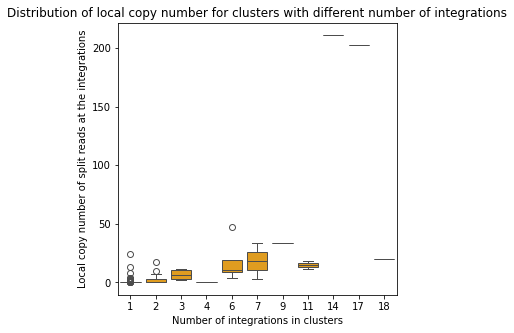

<Figure size 432x288 with 0 Axes>

In [52]:
fig,(ax1) = plt.subplots(figsize = [5,5])
sns.boxplot(x="NumIns", y="SPCov", data=sortedSPCovDf,color = 'orange',ax = ax1)
ax1.set_xlabel('Number of integrations in clusters')
ax1.set_ylabel('Local copy number of split reads at the integrations')
ax1.set_title('Distribution of local copy number for clusters with different number of integrations')
plt.show()
plt.savefig('CL_ins_loc_sp_04_23_25.pdf')

In [53]:
# #violin plot
# fig,ax = plt.subplots(figsize = [15,3])
# ax.violinplot(sortedSPCovDic, widths = 0.7)
# labels = sorted(SPCovDic.keys())
# print(labels)
# ax.set_xticklabels(labels=labels)
# #set_axis_style(ax,labels)

# i = 0
# ax.plot(sorted(SPCovDic),SPmedian)
# for each in sorted(SPCovDic):
#     ax.scatter(x = [each]*len(SPCovOutliers[i]),y = SPCovOutliers[i],edgecolors = 'red',s = 10,facecolors = 'none')
#     i += 1

In [54]:
#surrouding copy number
recurSurSPDic = {}
for patient in clusteredSiteRes:
    recurSurSPDic[patient] = {}
    sample = 'Sample_' + patient
    if clusteredSiteRes[patient] != {} and all_dic[sample] != {}:
        for chro in clusteredSiteRes[patient]:
            for eachCluster in clusteredSiteRes[patient][chro]:
                for site in eachCluster:
                    site1 = site.split(';')[0]
                    ins = chro+'.'+str(site1)
                    if ins in all_dic[sample]:

                        outputFilePath = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/clusterReadDepth/{sample}/'
                        outputFile = f'{outputFilePath}/{site1}_read_depth.txt'
                        covList = []
                        if ins not in recurSurSPDic[patient]:
                            recurSurSPDic[patient][ins] = []
                        with open(outputFile) as inputFile:
                            inputFile.readline()
                            rows = inputFile.read().rstrip().split('\n')
                            for row in rows:
                                if row != '':
                                    normSP = float(row.split('\t')[2])
                                    covList.append(normSP)
                        cov = max(covList)            
                        recurSurSPDic[patient][ins].append(cov)


In [55]:
recurSurSPDic

{'6670-CB-87': {'1.182207603': [0.09770950854348415]},
 '6670-CB-88': {},
 '2655-CB-91': {'9.26645008': [0.1454274050368092],
  '9.116921587': [0.242379008394682],
  '9.97813335': [46.68219701681575],
  '9.97814224': [0.1454274050368092],
  '9.97833766': [9.598208732429407],
  '9.97857784': [7.3683218551983325],
  '9.97860564': [3.8295883326359754],
  '9.97869989': [3.296354514167675],
  '9.97901339': [3.6841609275991662],
  '9.97902954': [1.5027498520470284],
  '9.97908821': [4.84758016789364],
  '9.97914603': [137.67127676817938],
  '9.97940224': [5.089959176288322],
  '9.97942608': [455.13930196353385],
  '9.97942781': [140.43439746387875],
  '9.97952091': [353.0977394293727],
  '9.99956760': [6.59270902833535],
  '2.32916236': [2.035983670515329],
  '2.151136063': [7.659176665271951],
  '6.79484344': [0.242379008394682],
  '11.131789342': [0.242379008394682],
  '8.46619611': [0.1939032067157456],
  '3.81785783': [3.6841609275991662],
  '3.81992132': [12.555232634844527],
  '3.82226

In [56]:
# if it's recurrent samples, count the largest sp number
# for patient in recurSurSPDic:
#     for ins in recurSurSPDic[patient]:
#         chro = ins.split('.')[0]
#         site = int(ins.split('.')[1])
#         if len(recurSurSPDic[patient][ins]) > 1:
#             sp = max(recurSurSPDic[patient][ins])
#         else:
#             sp = recurSurSPDic[patient][ins][0]
#         for cluster in clusteredSiteRes[patient][chro]:
#             i = 0
#             for ins2 in cluster:
#                 if ins2.split(';')[0] == str(site):
#                     #print(site)
#                     cluster[i] = str(ins2) +';' + str(sp)
#                 i += 1
            
        

In [57]:
#add other samples
for patient in clusteredSiteRes:
    sample = 'Sample_' + str(patient)
#         if sample != 'Sample_2655-CB-45':
    if clusteredSiteRes[patient] != {} and all_dic[sample] != {}:
        for chro in clusteredSiteRes[patient]:
            for eachCluster in clusteredSiteRes[patient][chro]:
                #print(eachCluster)
                i = 0
                for site in eachCluster:
                    site1 = site.split(';')[0]
                    ins = chro+'.'+str(site1)
                    if ins in all_dic[sample]:
                        outputFilePath = f'/home/wenjingu/scratch/HPV_fusion/targeted_exom/our_res/clusterReadDepth/{sample}/'
                        outputFile = f'{outputFilePath}/{site1}_read_depth.txt'
                        covList = []
                        with open(outputFile) as inputFile:
                            inputFile.readline()
                            rows = inputFile.read().rstrip().split('\n')
                            for row in rows:
                                if row != '':
                                    normSP = float(row.split('\t')[2])
                                    covList.append(normSP)
                        #print(sample,site1)            
                        cov = max(covList)
                        #print(str(site) +';' + str(cov))
                        eachCluster[i] = str(site) +';' + str(cov)
                    i += 1







In [58]:
clusteredSiteRes

{'6670-CB-87': {'1': [['182207603;0.048854754271742074;0.09770950854348415']]},
 '6670-CB-88': {},
 '2655-CB-91': {'9': [['26645008;0.1454274050368092;0.1454274050368092'],
   ['116921587;0.0484758016789364;0.242379008394682'],
   ['97813335;23.1714332025316;46.68219701681575',
    '97814224;0.0484758016789364;0.1454274050368092',
    '97833766;4.6536769611778945;9.598208732429407',
    '97857784;2.811596497378311;7.3683218551983325',
    '97860564;1.1634192402944736;3.8295883326359754',
    '97869989;1.1149434386155372;3.296354514167675',
    '97901339;1.1149434386155372;3.6841609275991662',
    '97902954;1.1634192402944736;1.5027498520470284',
    '97908821;2.9570239024151204;4.84758016789364',
    '97914603;56.4743089559609;137.67127676817938',
    '97940224;2.42379008394682;5.089959176288322',
    '97942608;210.82126150169438;455.13930196353385',
    '97942781;0.0484758016789364;140.43439746387875',
    '97952091;102.23546574087686;353.0977394293727'],
   ['99956760;3.8295883326359

In [59]:
#distribution of highest copy number and number of integration in cluster
SurCovDic = {}
for patient in clusteredSiteRes:
    for chro in clusteredSiteRes[patient]:
        for cluster in clusteredSiteRes[patient][chro]:
            key = len(cluster)
            covList = []
            for ins in cluster:
                #print(cluster,ins)
                if key == 1 and float(ins.split(';')[2]) > 100:
                    print(patient,chro,ins,cluster)
                covList.append(float(ins.split(';')[2]))
            if key in SurCovDic:
                SurCovDic[key].append(max(covList))
            else:
                SurCovDic[key] = [max(covList)]

            

In [60]:
MAP2K4['Sample_109365']

46.50794747753974

In [61]:
sortedSurCovDic = []
for numIns in sorted(SurCovDic):
    for each in SurCovDic[numIns]:
        sortedSurCovDic.append([numIns,each])
sortedSurCovDf = pd.DataFrame(sortedSurCovDic,columns = ['NumIns','SPCov'])

In [62]:
sortedSurCovDic

[[1, 0.09770950854348415],
 [1, 0.1454274050368092],
 [1, 0.242379008394682],
 [1, 6.59270902833535],
 [1, 2.035983670515329],
 [1, 7.659176665271951],
 [1, 0.242379008394682],
 [1, 0.242379008394682],
 [1, 0.1939032067157456],
 [1, 0.1454274050368092],
 [1, 0.1939032067157456],
 [1, 0.1939032067157456],
 [1, 1.8420804637995831],
 [1, 0.1454274050368092],
 [1, 0.08001390268656876],
 [1, 0.9068242304477794],
 [1, 1.333565044776146],
 [1, 8.348117180298674],
 [1, 0.9334955313433022],
 [1, 30.59198212716479],
 [1, 0.10668520358209169],
 [1, 19.565138315070953],
 [1, 2.162625202567649],
 [1, 3.327115696257922],
 [1, 0.12476683860967207],
 [1, 0.12476683860967207],
 [1, 0.24953367721934414],
 [1, 0.1663557848128961],
 [1, 0.1663557848128961],
 [1, 0.20794473101612013],
 [1, 0.1663557848128961],
 [1, 0.12476683860967207],
 [1, 0.1663557848128961],
 [1, 1.788324686738633],
 [1, 0.07766943824429043],
 [1, 0.10355925099238723],
 [1, 5.895104871288247],
 [1, 0.866615221094626],
 [1, 2.3831918580

In [63]:
sortedSurCovDf

,NumIns,SPCov
0,1,0.097710
1,1,0.145427
2,1,0.242379
3,1,6.592709
4,1,2.035984
...,...,...
169,11,25.425494
170,11,27.383641
171,14,455.139302
172,17,489.501897


In [64]:
sortedSurCovDic = {}
for numIns in sorted(SurCovDic):
    sortedSurCovDic[numIns] = SurCovDic[numIns]
    

In [65]:
sortedSurCovDf

,NumIns,SPCov
0,1,0.097710
1,1,0.145427
2,1,0.242379
3,1,6.592709
4,1,2.035984
...,...,...
169,11,25.425494
170,11,27.383641
171,14,455.139302
172,17,489.501897


In [66]:
SurCovOutliers = []
Surmedian = []
numInsList = []
for each in sortedSurCovDic.values():
        
    row = np.array(each)
    q1, q3 = np.percentile(row, [25, 75])
    low = q1 - (q3 - q1) * 1.5
    high = q3 + (q3 - q1) * 1.5
    outliers =  row[(row < low) | (row > high)]
    SurCovOutliers.append(outliers)
    Surmedian.append(np.median(each))
    numInsList.append(len(each))

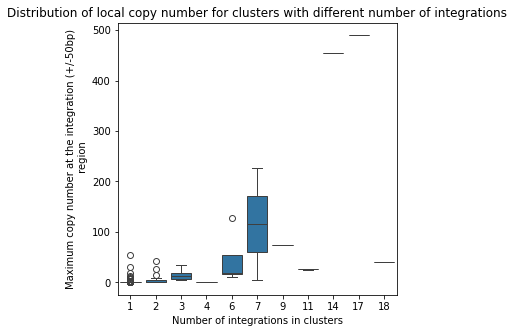

In [67]:
fig,(ax1) = plt.subplots(figsize = [5,5])
sns.boxplot(x="NumIns", y="SPCov", data=sortedSurCovDf,color = 'tab:blue',ax = ax1)
ax1.set_xlabel('Number of integrations in clusters')
ax1.set_ylabel('Maximum copy number at the integration (+/-50bp)\n region')
ax1.set_title('Distribution of local copy number for clusters with different number of integrations')
plt.savefig('CL_ins_sr_sp.pdf')

In [68]:
sortedSurCovDf['SurCov'] = sortedSPCovDf['SPCov']

In [69]:
sortedSurCovDf['Classify'] = 'Maximum copy number of all reads at surrunding region(+/-50bp)'
sortedSPCovDf['Classify'] = 'Local copy number of split reads'
sortedCombinDf = pd.concat([sortedSurCovDf,sortedSPCovDf])

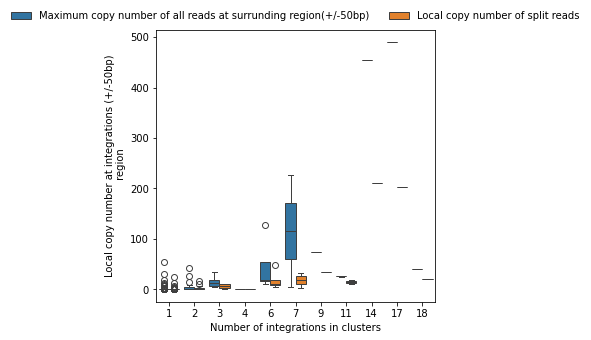

In [70]:
fig,(ax1) = plt.subplots(figsize = [5,5])
sns.boxplot(x="NumIns", y="SPCov", hue = 'Classify',data=sortedCombinDf,ax = ax1)
ax1.set_xlabel('Number of integrations in clusters')
ax1.set_ylabel('Local copy number at integrations (+/-50bp)\n region')
#ax1.set_title('Distribution of local copy number for clusters with different number of integrations')
sns.move_legend(ax1, "lower center", bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False)
plt.savefig('CL_ins_sp.pdf')

In [71]:
#try different cut off
def defineDup(SPCutOff, SurCutOff, lenClusterCutOff):
    DupCountDic = {}
    for patient in clusteredSiteRes:
        DupCountDic[patient] = {}
        for chro in clusteredSiteRes[patient]:
            DupCountDic[patient][chro] = []
            for cluster in clusteredSiteRes[patient][chro]:
                spList = []
                surList = []
                for each in cluster:
                    sp = each.split(';')[1]
                    sur = each.split(';')[2]
                    spList.append(float(sp))
                    surList.append(float(sur))
                maxSP =np.round(max(spList))
                maxSur = np.round(max(surList))
                lenCluster = len(cluster)
                #print(lenCluster)

                if maxSP > SPCutOff and maxSur > SurCutOff and lenCluster > lenClusterCutOff:
                    #print(maxSP,maxSur)
                    DupCountDic[patient][chro].append(cluster)
    return DupCountDic


In [72]:
clusteredSiteRes

{'6670-CB-87': {'1': [['182207603;0.048854754271742074;0.09770950854348415']]},
 '6670-CB-88': {},
 '2655-CB-91': {'9': [['26645008;0.1454274050368092;0.1454274050368092'],
   ['116921587;0.0484758016789364;0.242379008394682'],
   ['97813335;23.1714332025316;46.68219701681575',
    '97814224;0.0484758016789364;0.1454274050368092',
    '97833766;4.6536769611778945;9.598208732429407',
    '97857784;2.811596497378311;7.3683218551983325',
    '97860564;1.1634192402944736;3.8295883326359754',
    '97869989;1.1149434386155372;3.296354514167675',
    '97901339;1.1149434386155372;3.6841609275991662',
    '97902954;1.1634192402944736;1.5027498520470284',
    '97908821;2.9570239024151204;4.84758016789364',
    '97914603;56.4743089559609;137.67127676817938',
    '97940224;2.42379008394682;5.089959176288322',
    '97942608;210.82126150169438;455.13930196353385',
    '97942781;0.0484758016789364;140.43439746387875',
    '97952091;102.23546574087686;353.0977394293727'],
   ['99956760;3.8295883326359

In [73]:
countDupTotal = 0
countSampleTotal = 0
for patient in clusteredSiteRes:
    if clusteredSiteRes[patient] != {}:
        countSampleTotal += 1
        for chro in clusteredSiteRes[patient]:
            if clusteredSiteRes[patient][chro] != []:
                countDupTotal += 1

In [74]:
countSampleTotal

16

In [75]:
countDupTotal

96

/tmp/ipykernel_305076/4148585731.py:46: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = [10,3])


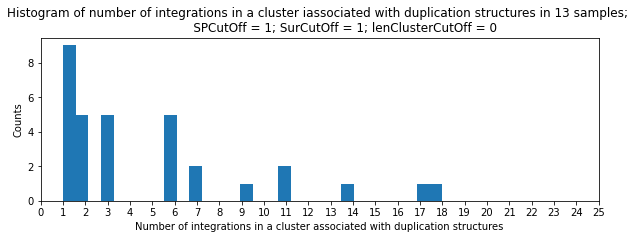

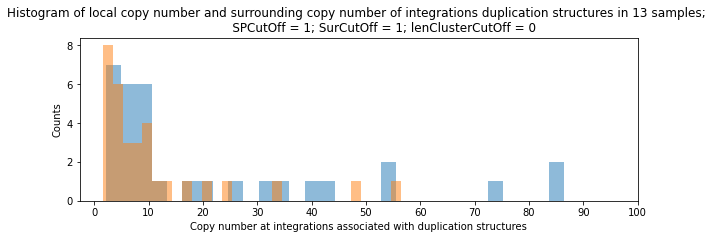

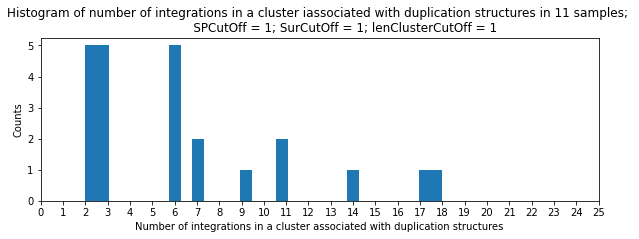

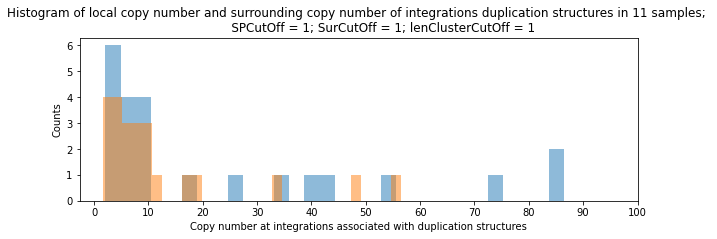

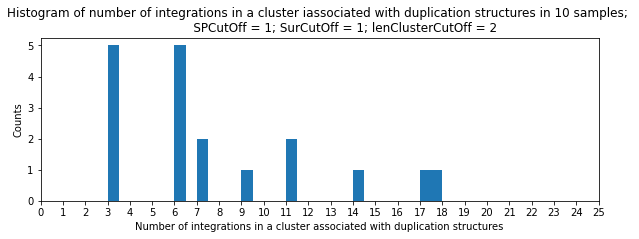

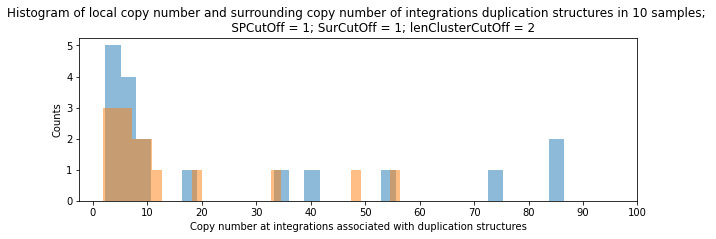

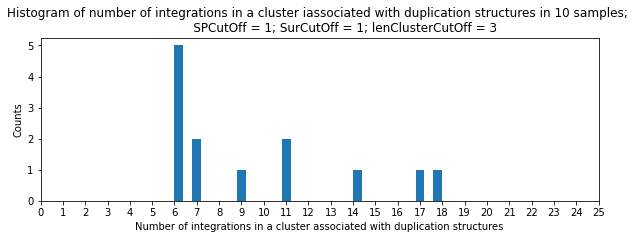

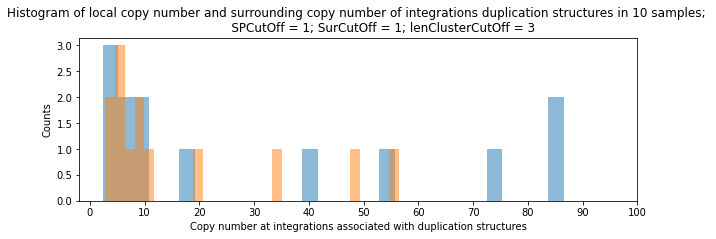

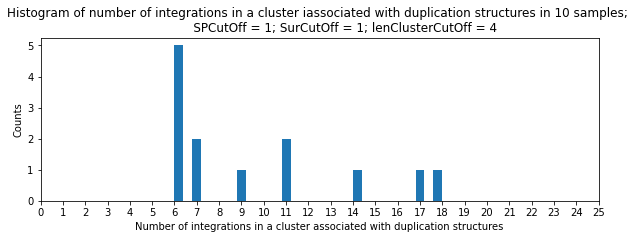

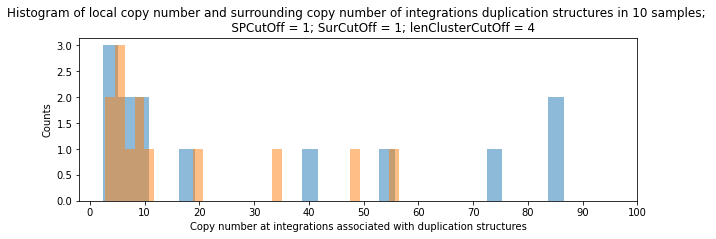

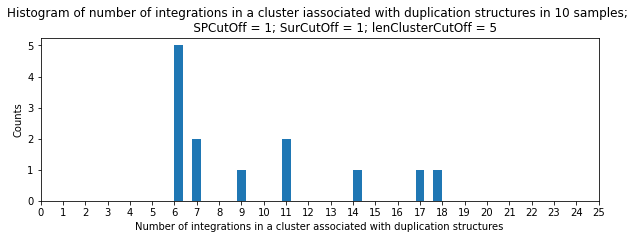

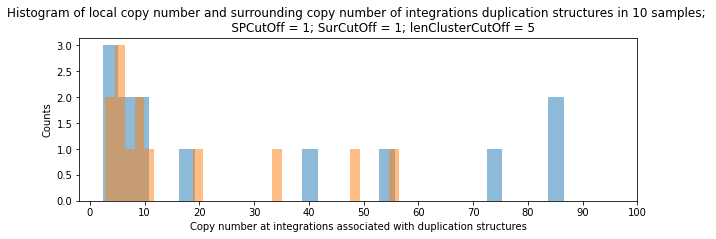

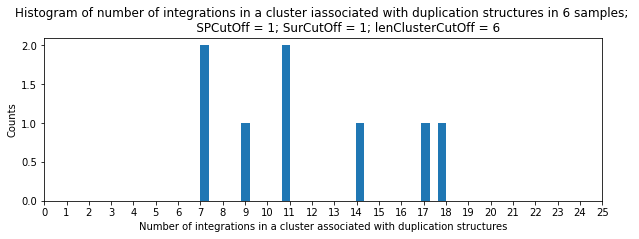

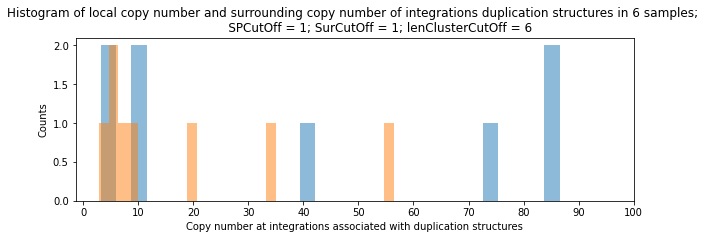

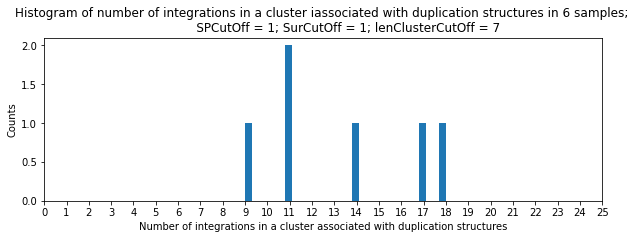

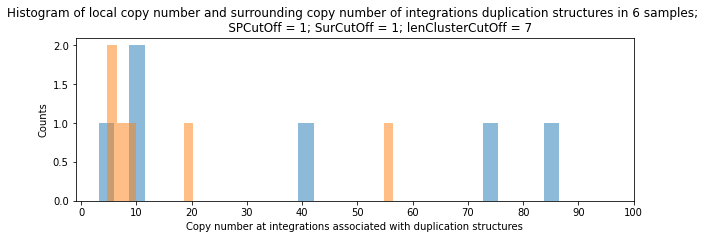

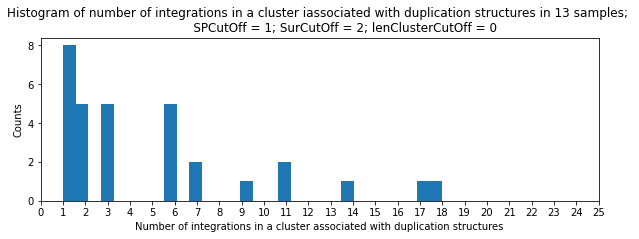

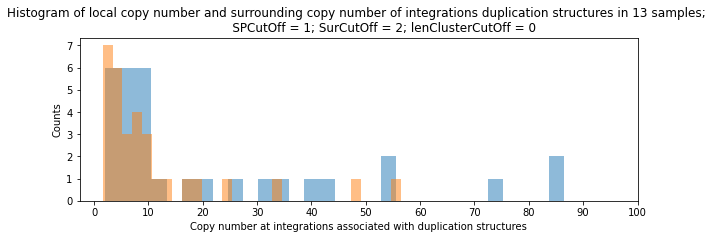

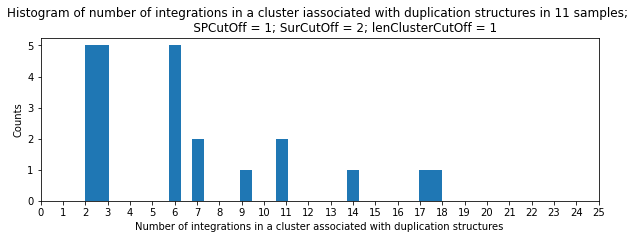

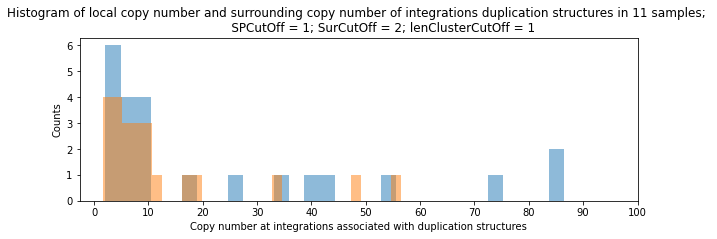

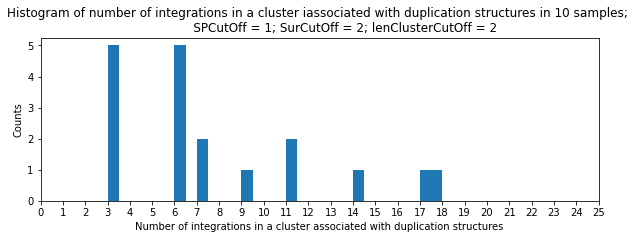

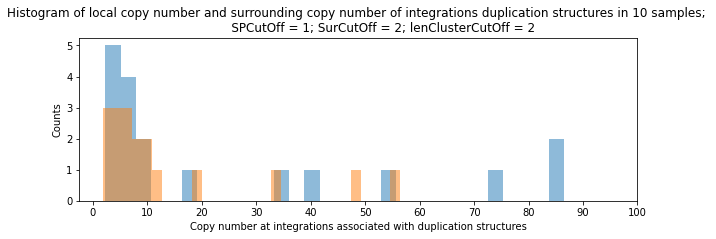

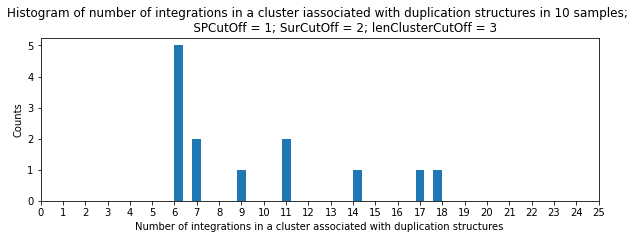

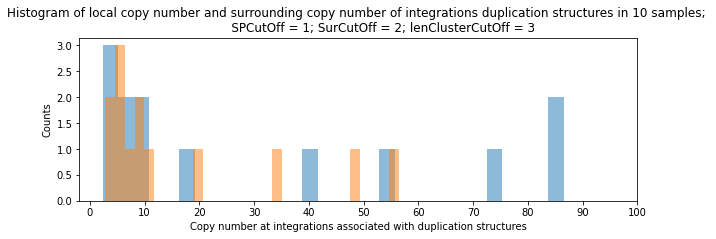

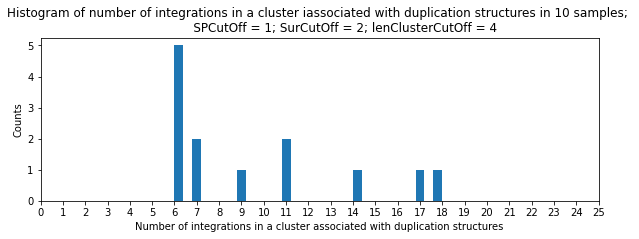

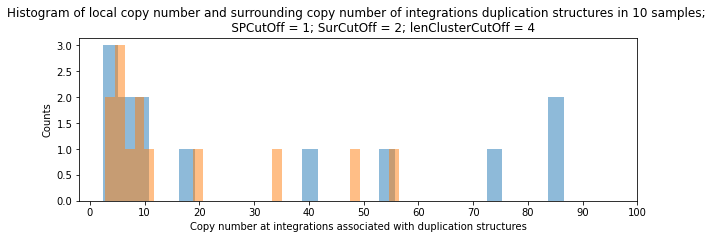

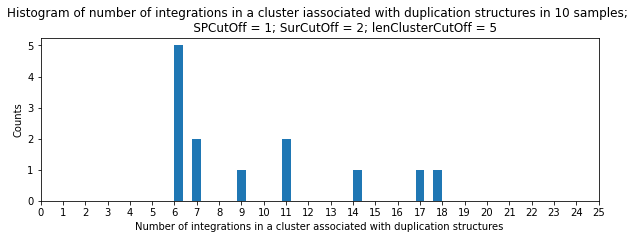

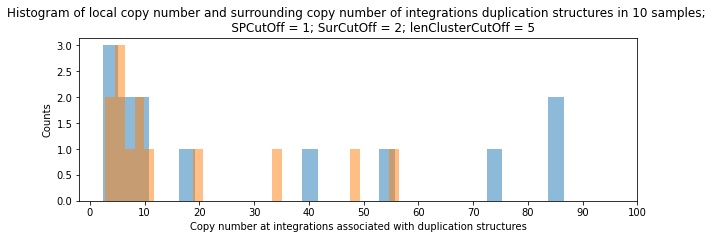

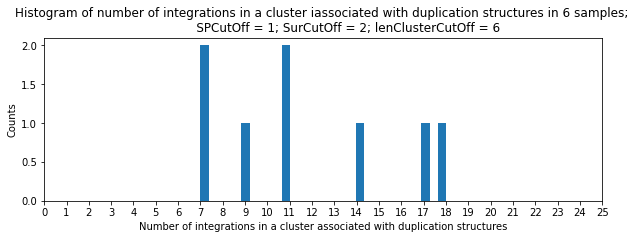

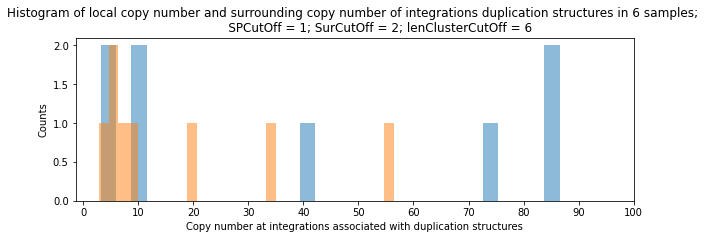

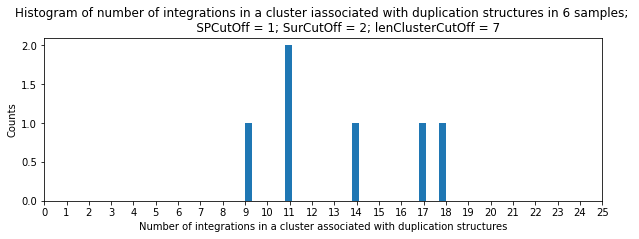

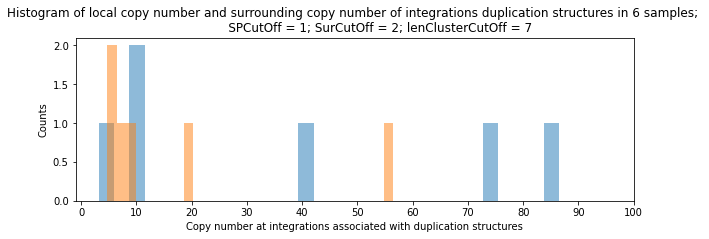

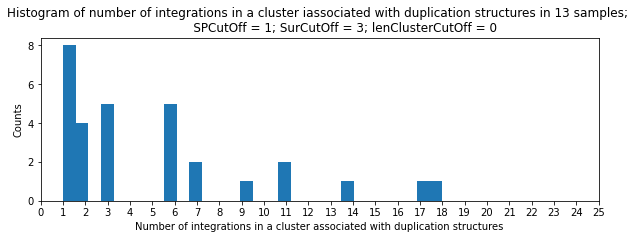

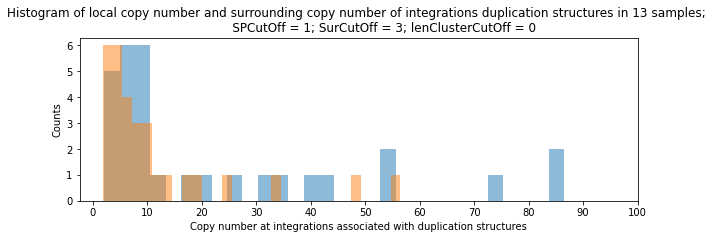

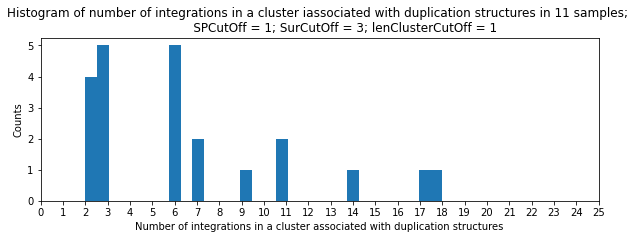

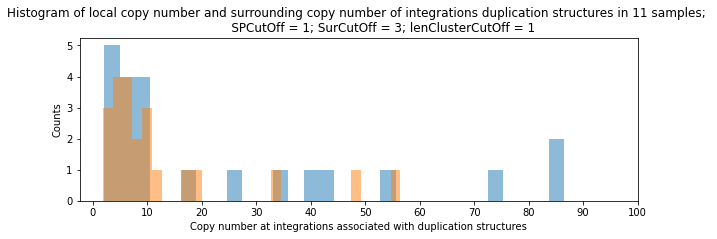

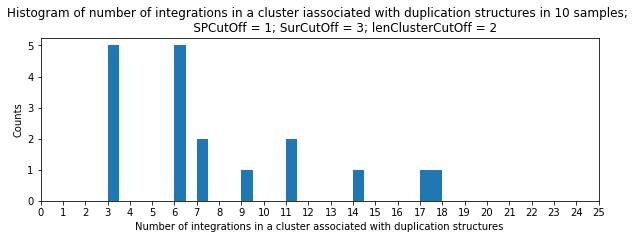

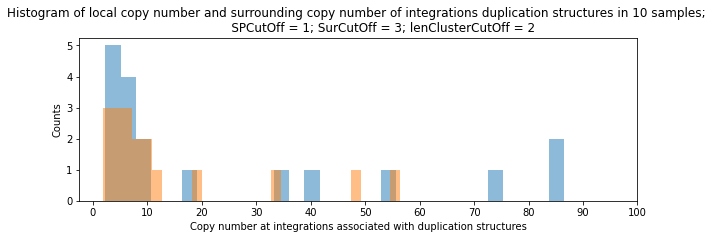

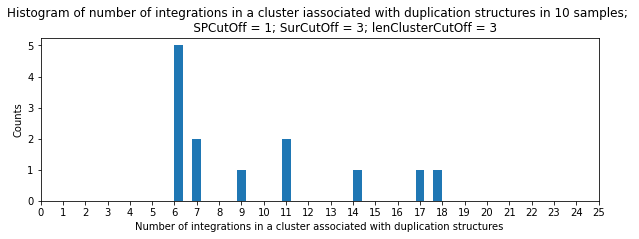

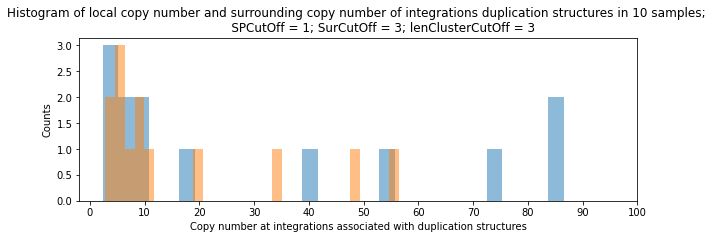

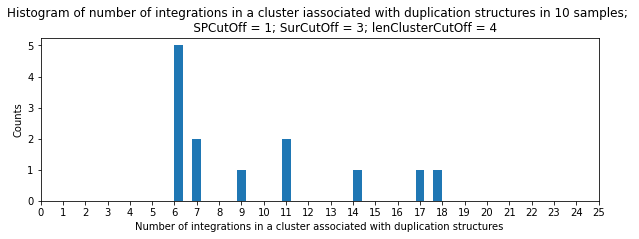

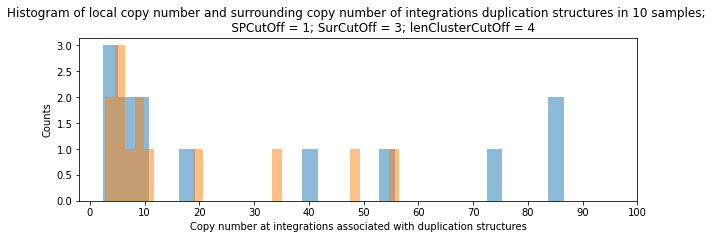

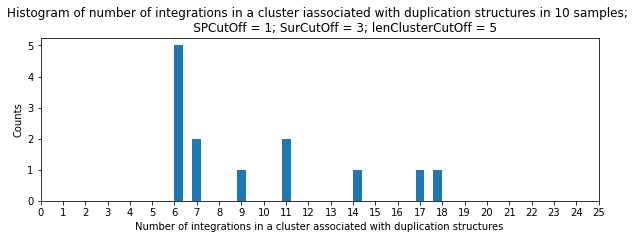

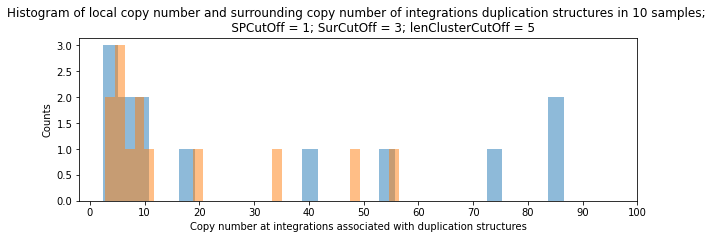

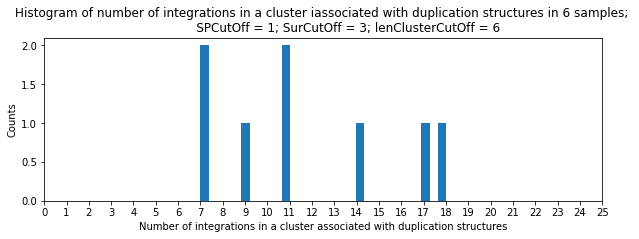

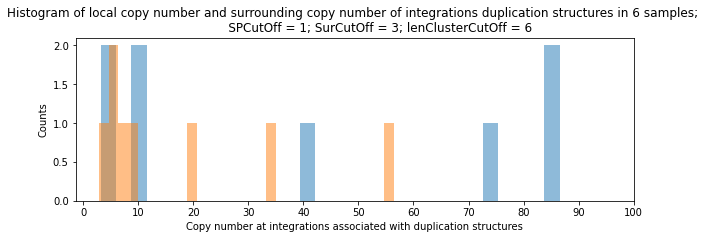

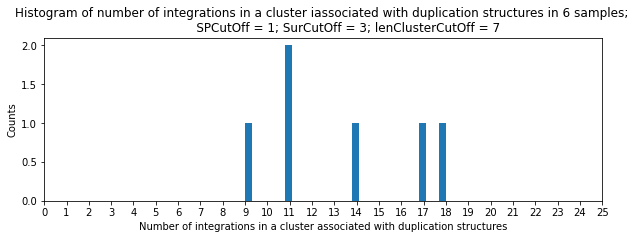

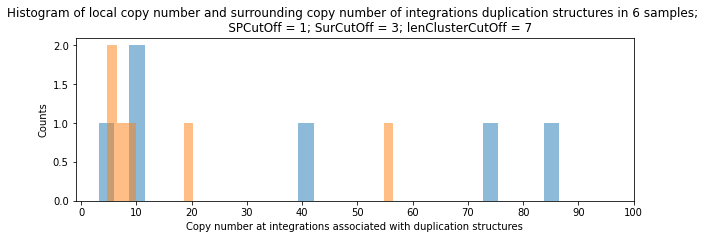

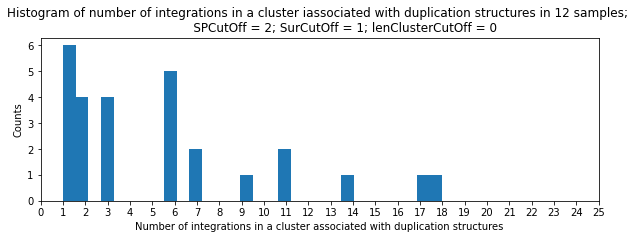

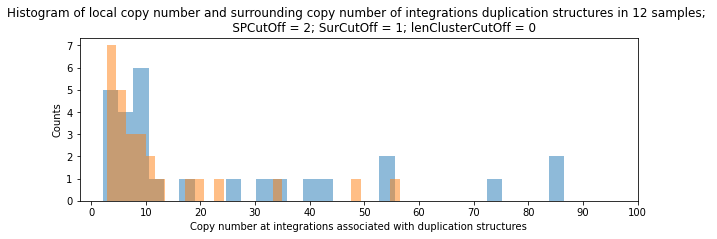

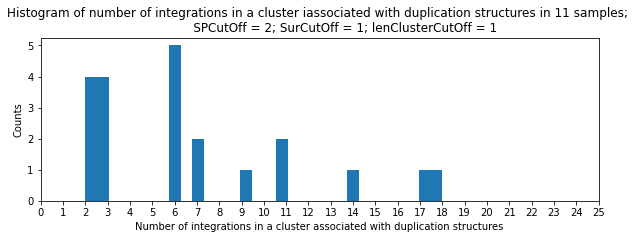

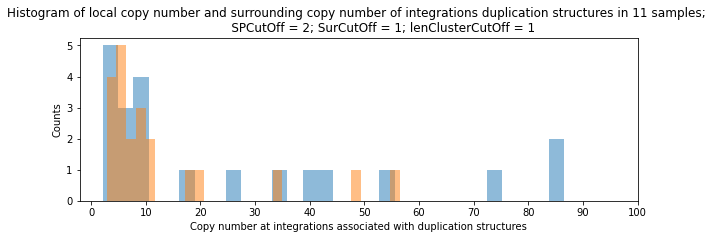

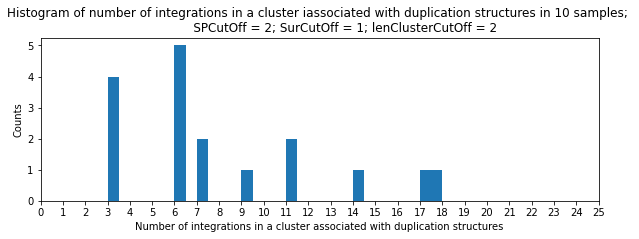

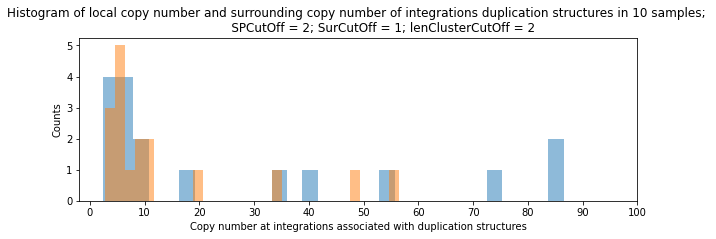

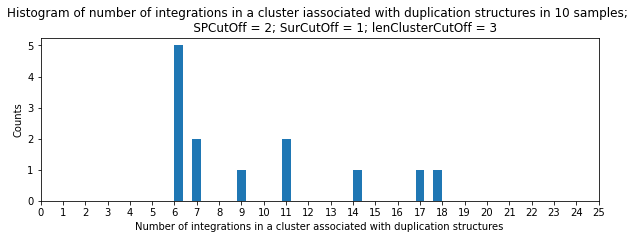

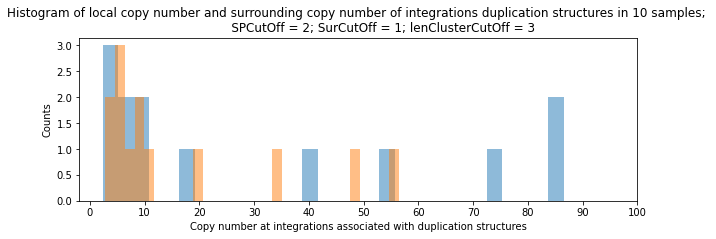

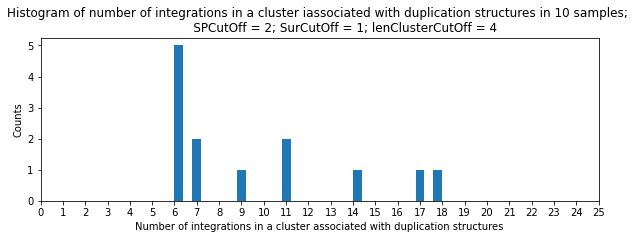

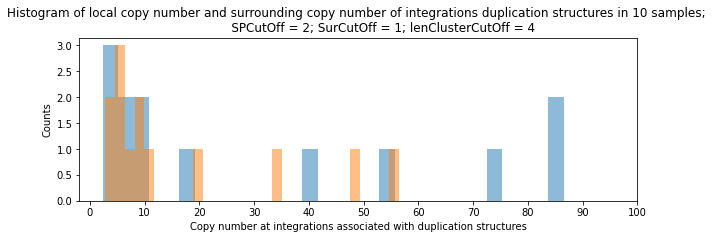

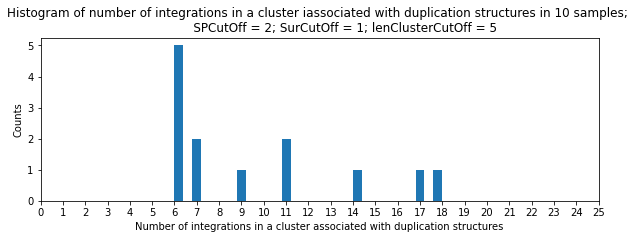

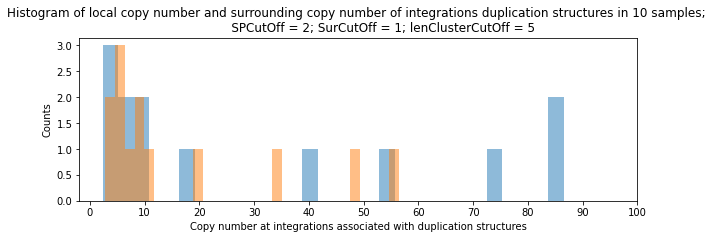

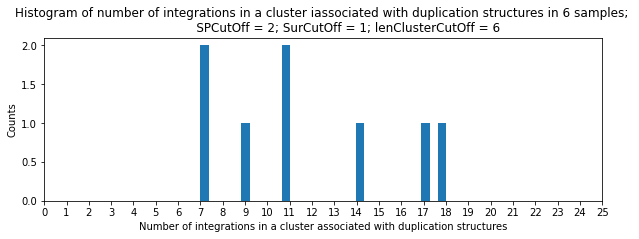

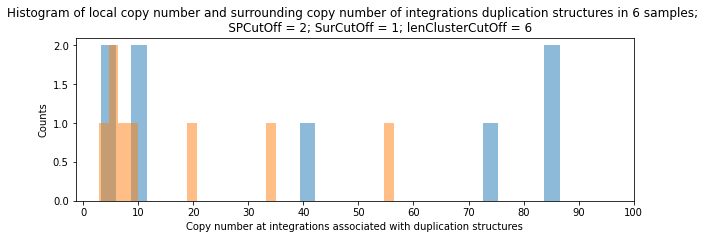

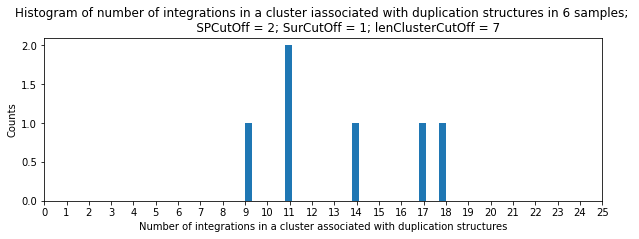

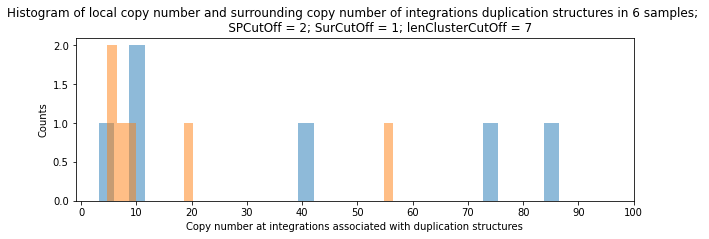

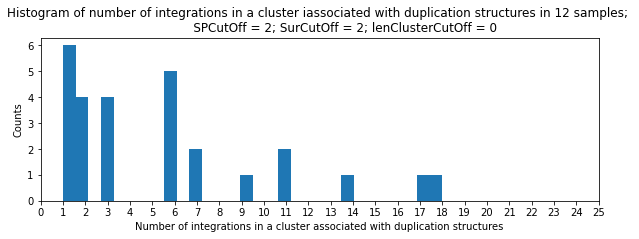

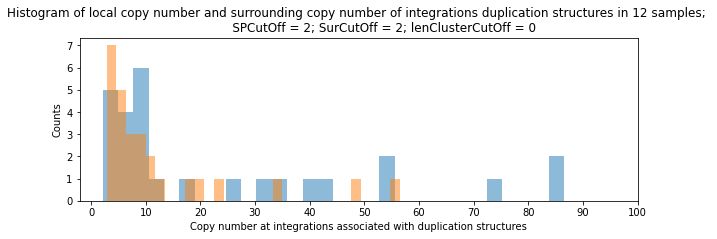

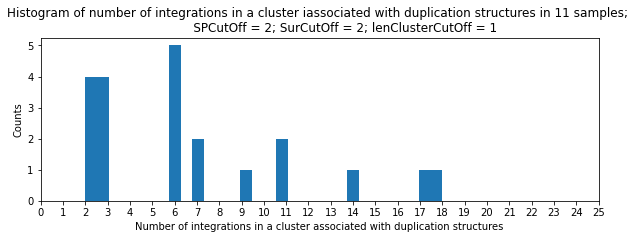

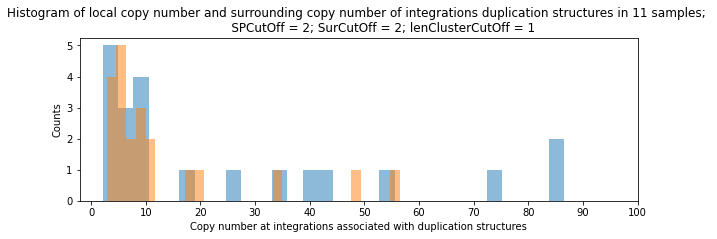

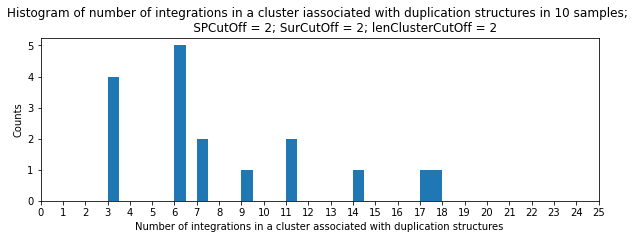

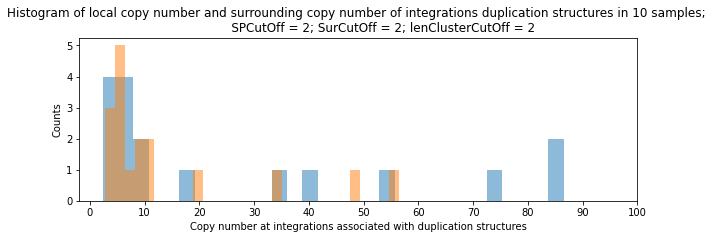

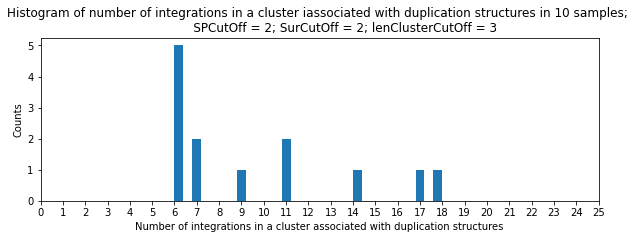

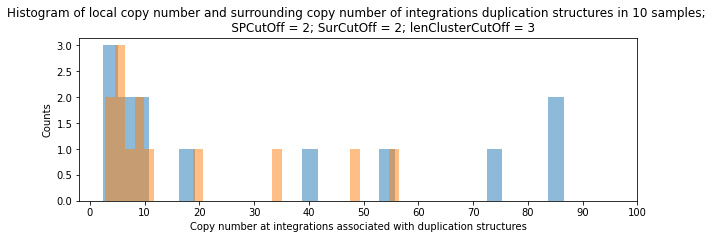

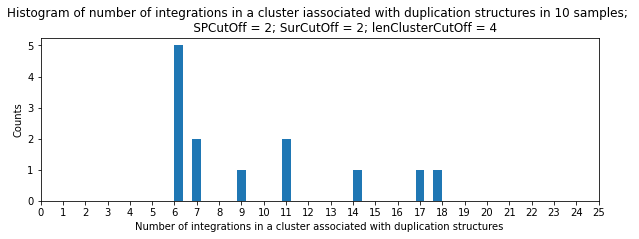

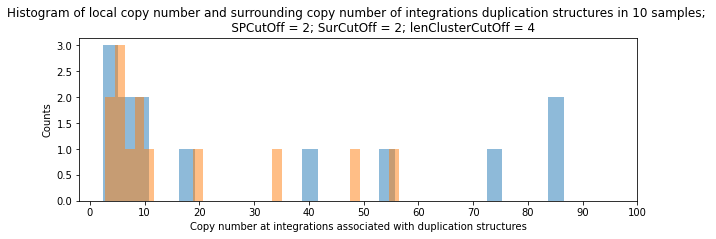

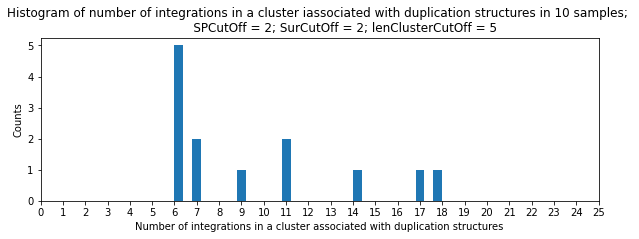

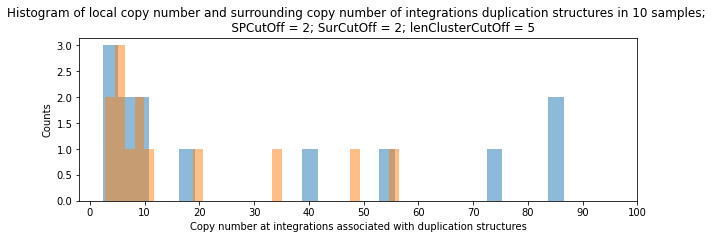

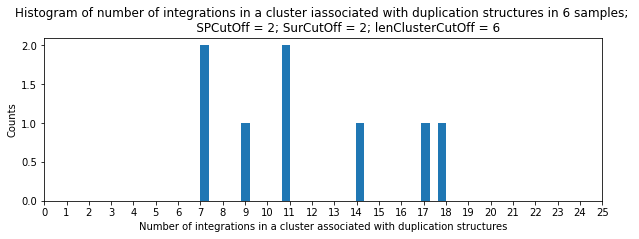

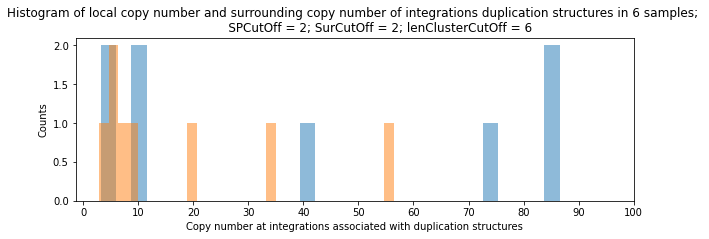

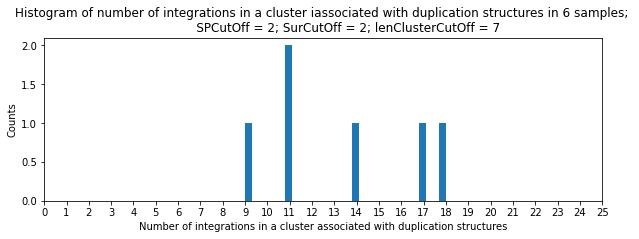

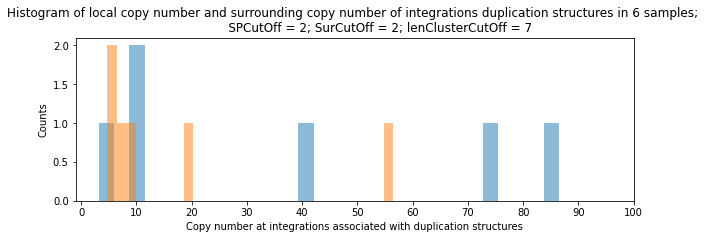

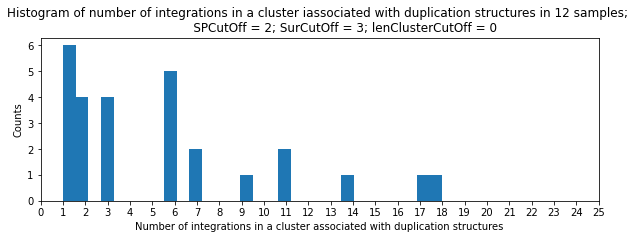

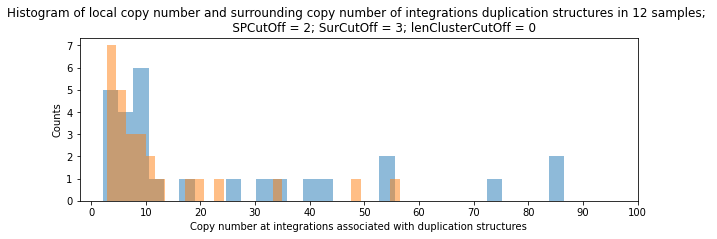

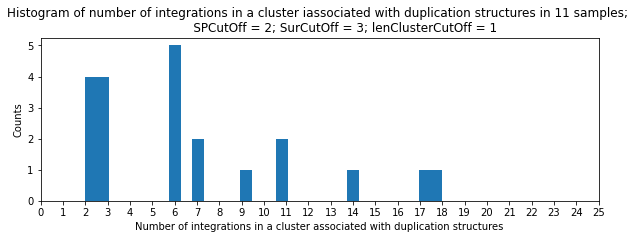

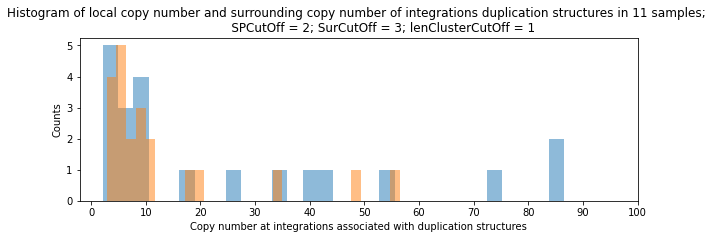

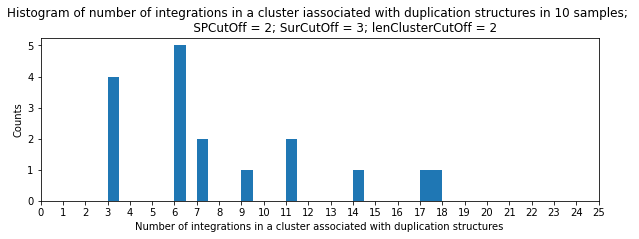

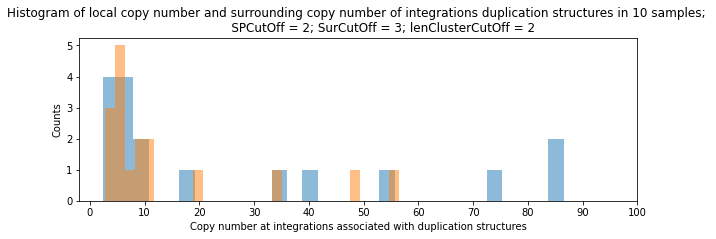

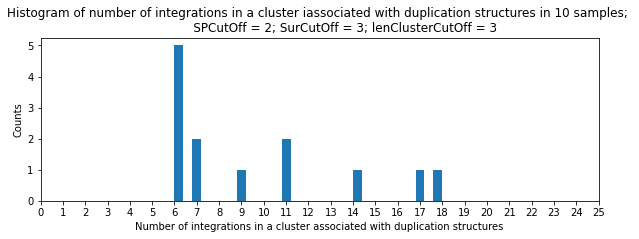

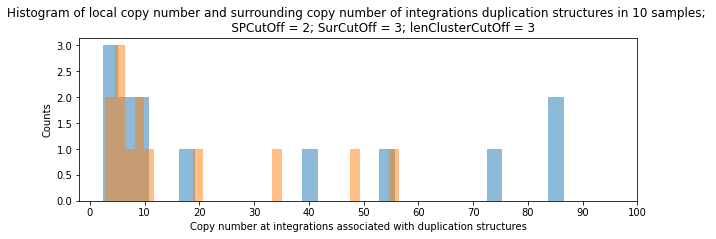

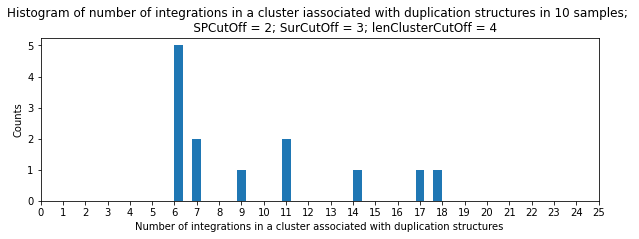

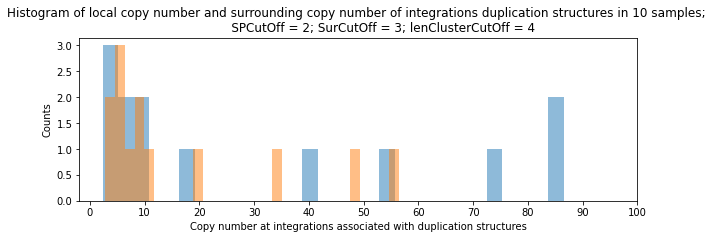

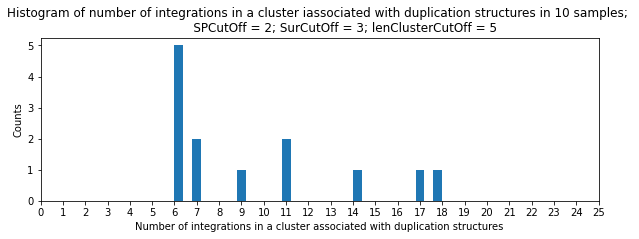

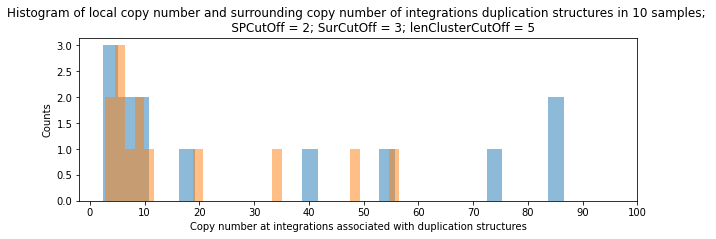

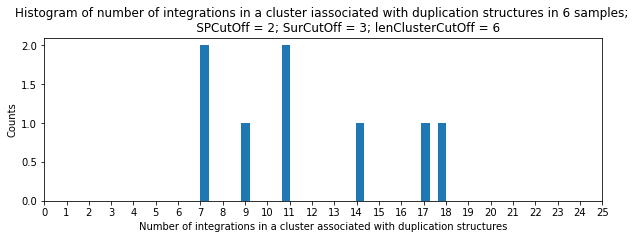

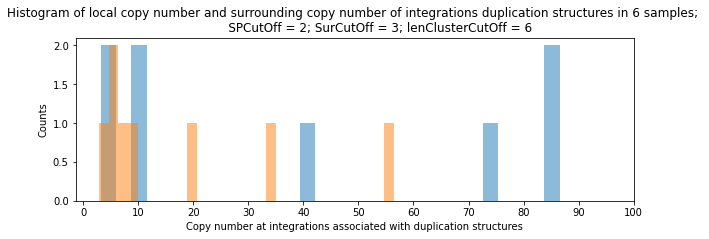

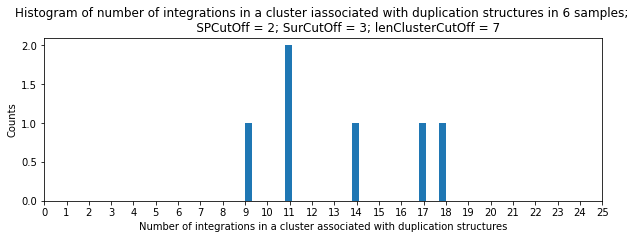

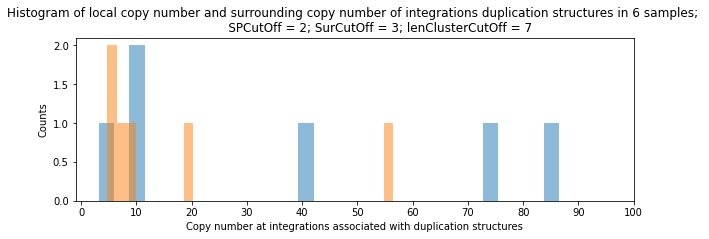

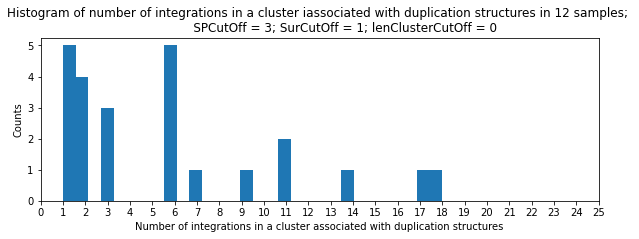

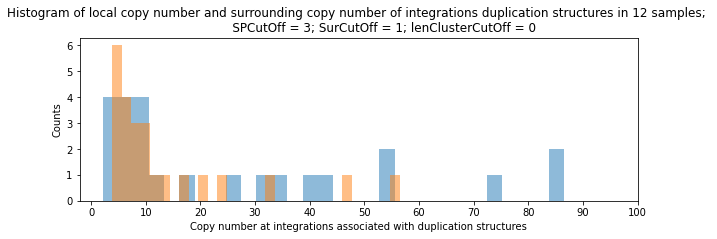

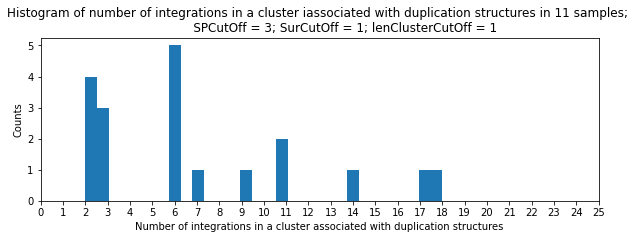

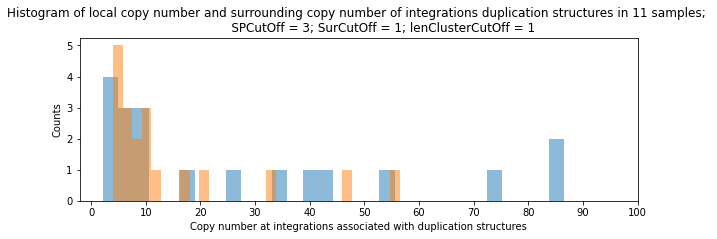

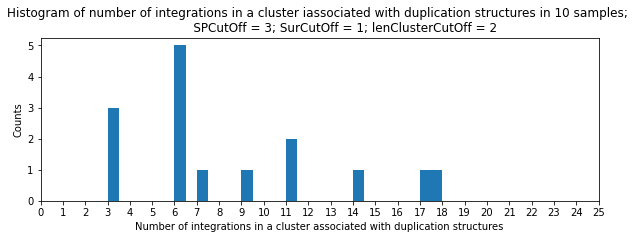

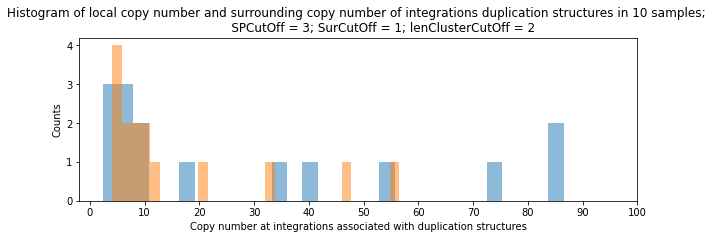

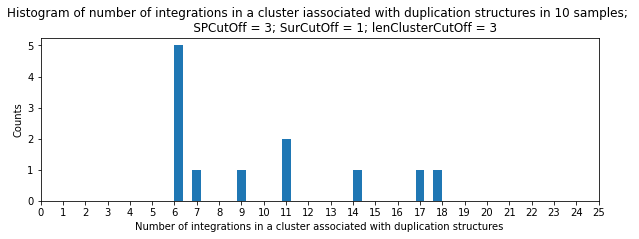

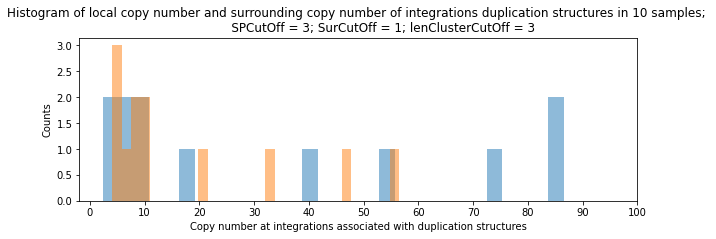

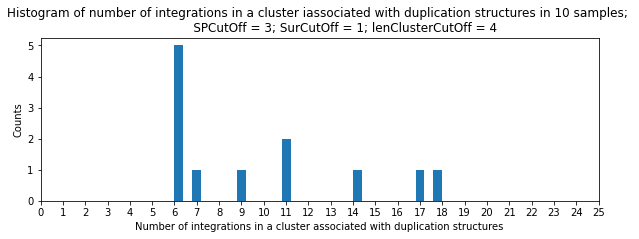

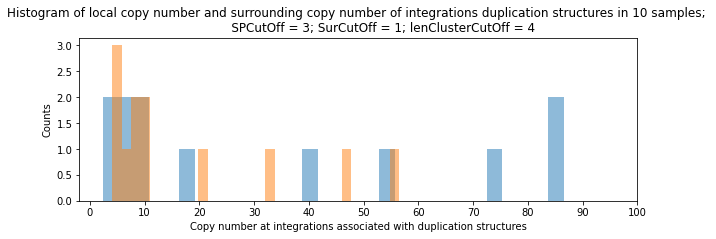

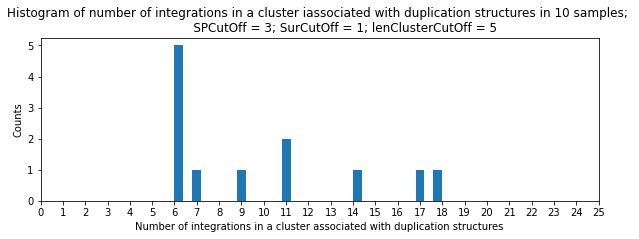

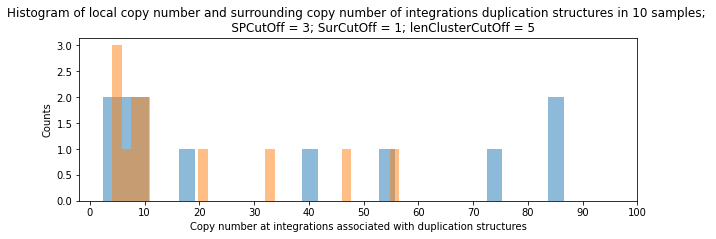

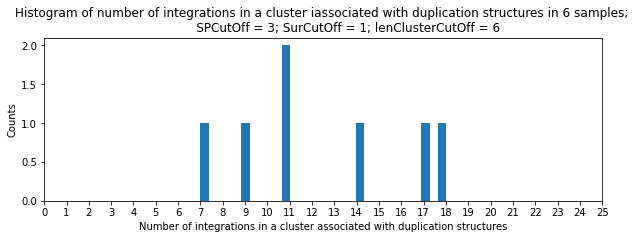

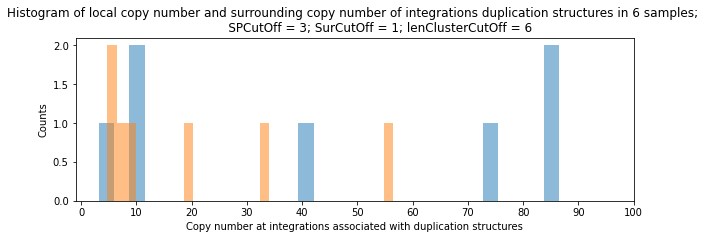

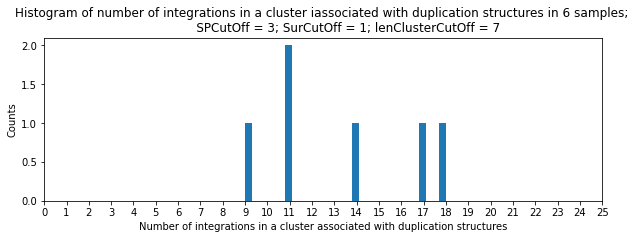

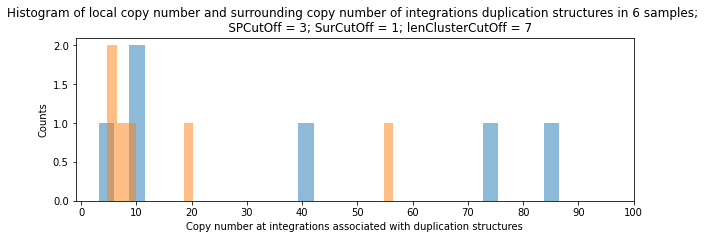

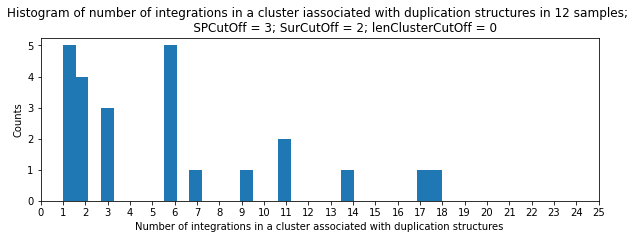

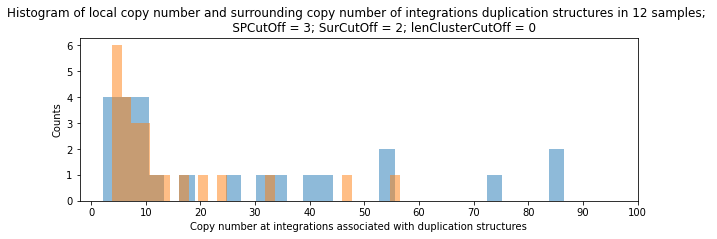

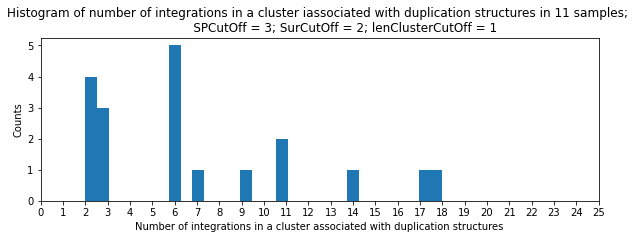

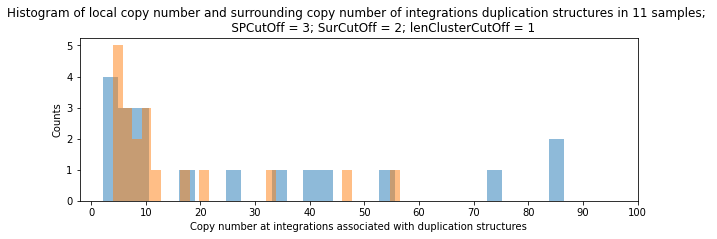

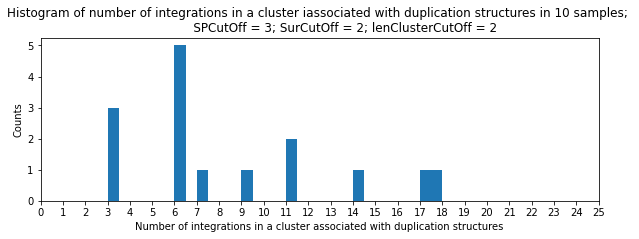

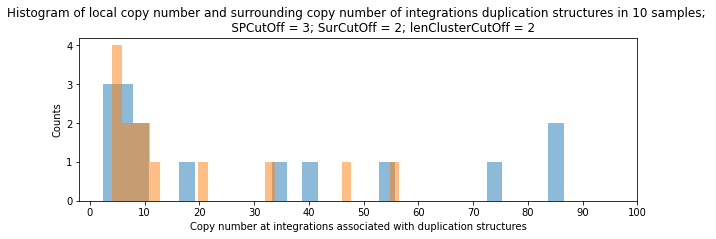

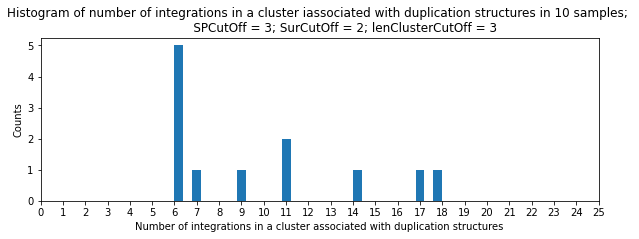

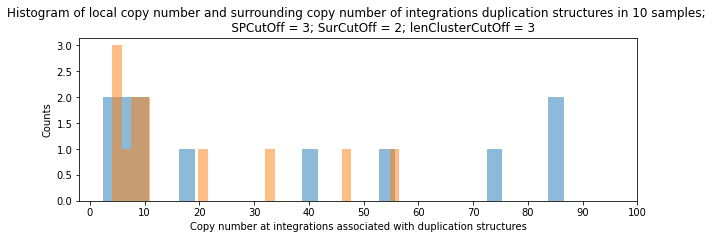

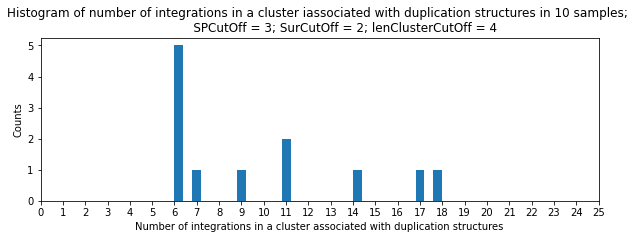

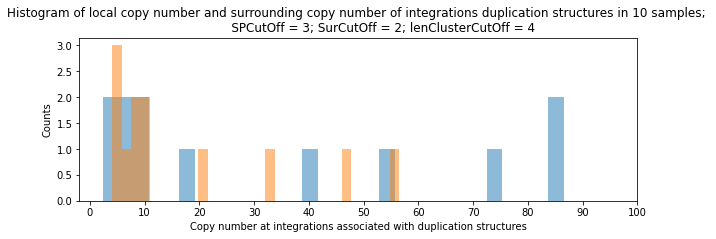

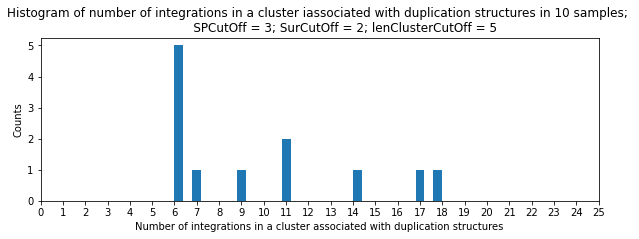

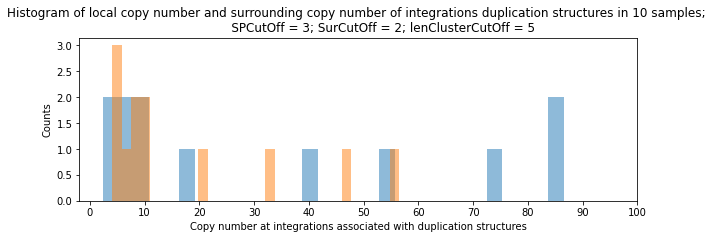

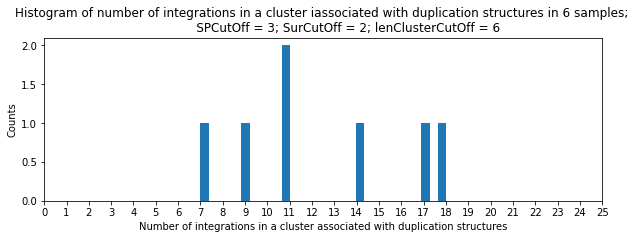

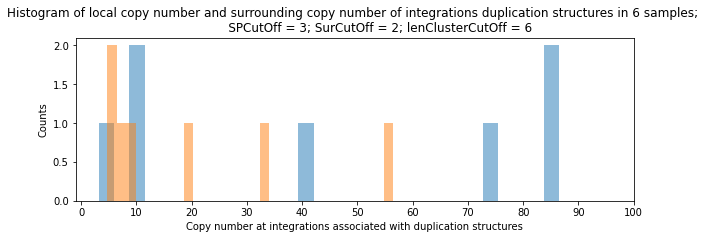

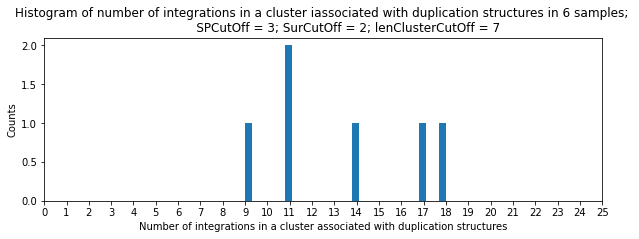

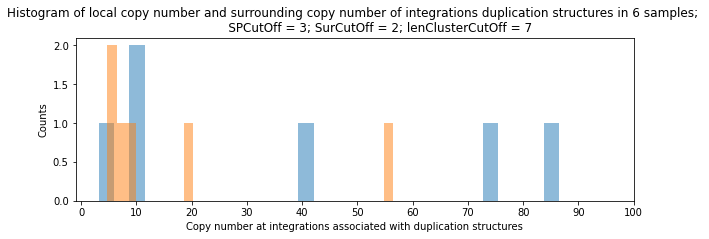

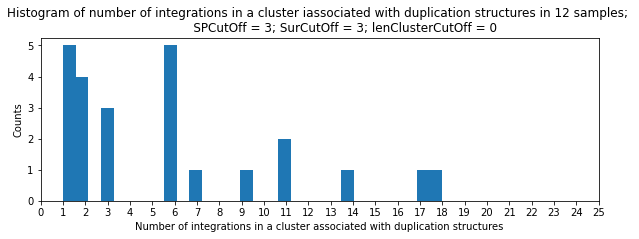

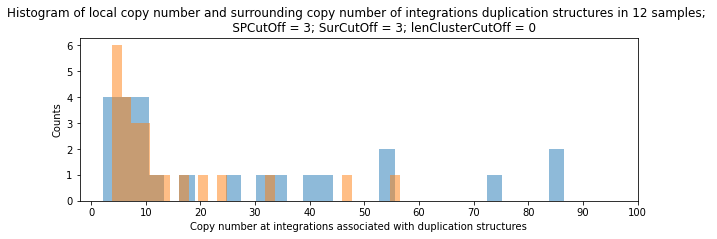

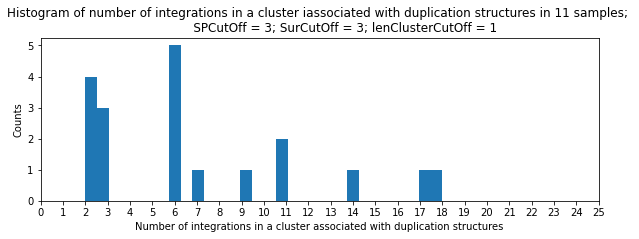

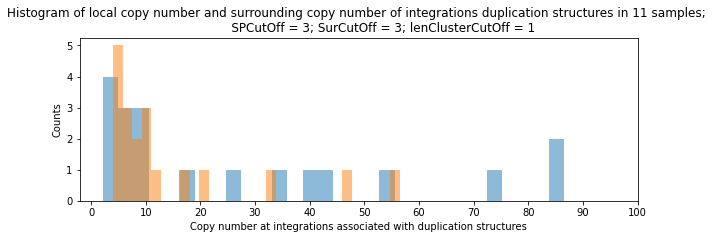

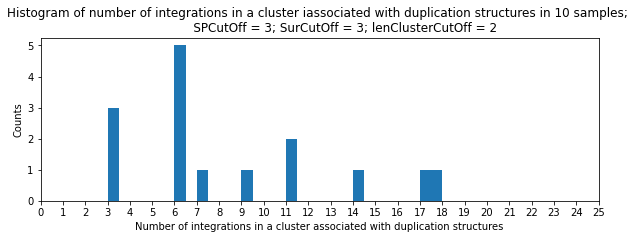

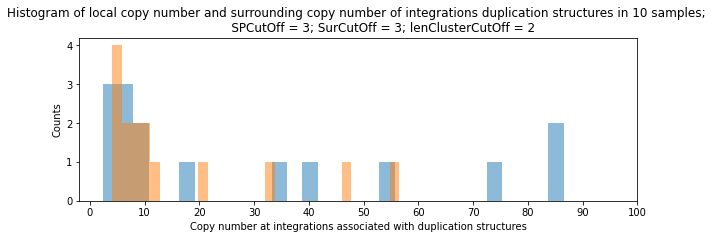

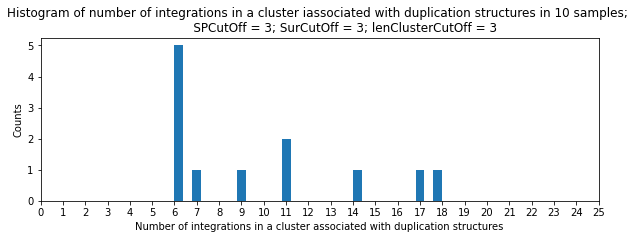

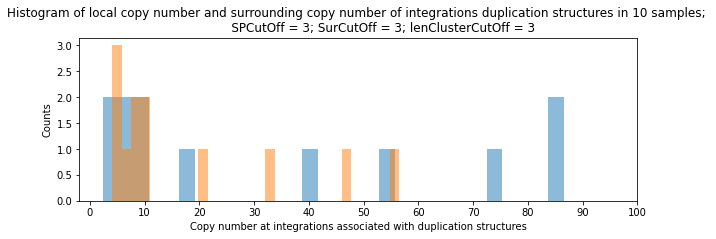

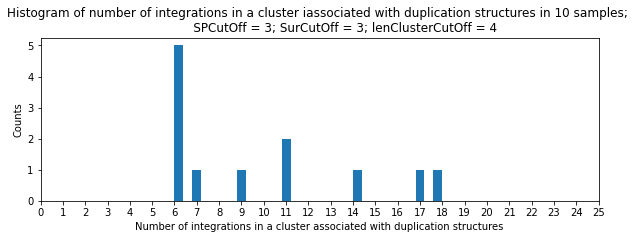

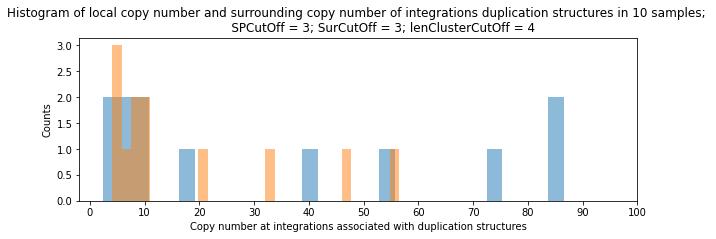

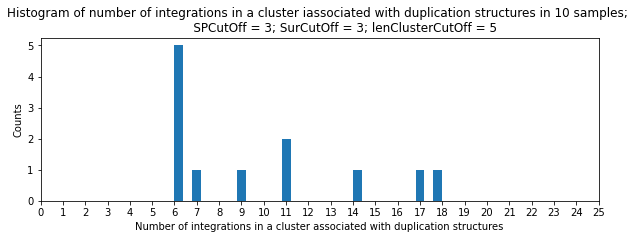

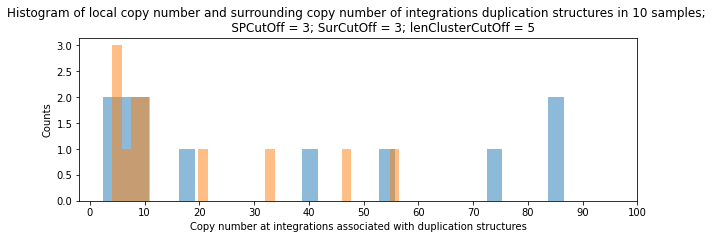

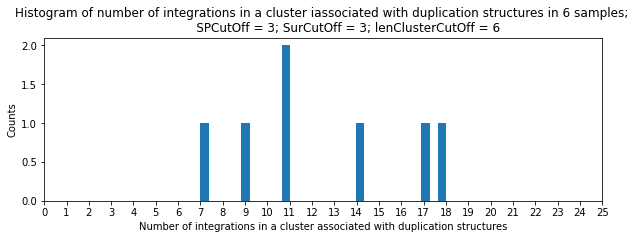

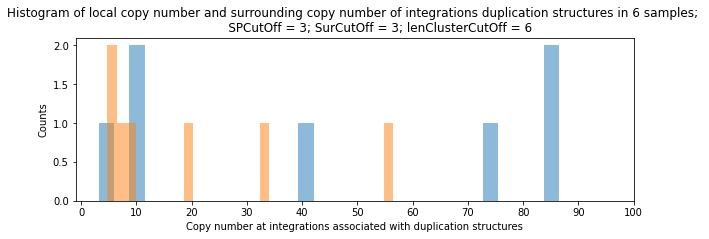

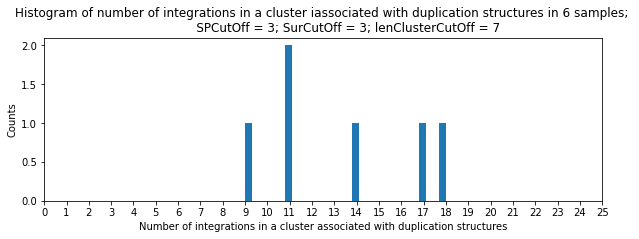

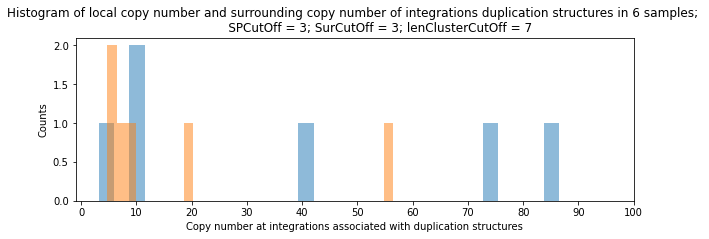

In [76]:
cutOffList = []
for SPCutOff in range(1,4):
    for SurCutOff in range(1,4):
        for lenClusterCutOff in range(0,8):
            DupCountDic= defineDup(SPCutOff, SurCutOff, lenClusterCutOff)
            #print(DupCountDic)
            #number of integration in cluster
            #copy number distribution
            numList = []
            maxSpList = []
            maxSurList = []
            countDup = 0
            countSample = 0
            for patient in DupCountDic:
                empty = True
                if DupCountDic[patient] != {}:
                    for chro in DupCountDic[patient]:
                        if DupCountDic[patient][chro] != []:
                            empty = False
                            for cluster in DupCountDic[patient][chro]:
                                countDup += 1
                                spList = []
                                surList = []
                                numList.append(len(cluster))
                                for each in cluster:
                                    spList.append(each.split(';')[1])
                                    surList.append(each.split(';')[2])
                                maxSP =max(spList)
                                maxSur = max(surList)
                                maxSpList.append(float(maxSP))
                                maxSurList.append(float(maxSur))
                if empty != True:
                    countSample += 1
            
            
            
            cutOffList.append([SPCutOff,SurCutOff,lenClusterCutOff,countSample,countDup])
            #samples
            cutOffListDf = pd.DataFrame(cutOffList,columns = ['SPCutOff','SurCutOff','lenClusterCutOff',\
                                                             'countSample','countDup'])
            
            
            
            #histogram of number of integrations in clusters in all patients 
            #cluster is defined for each sample seperately
            plt.figure(figsize = [10,3])
            plt.hist(numList,bins = 30)
            plt.xticks(range(0,26,1))
            #plt.yticks(range(0,max(y)+2,2))
            #plt.yscale('log', nonpositive='clip')
            plt.xlabel('Number of integrations in a cluster associated with duplication structures')
            plt.ylabel('Counts')
            plt.title(f'Histogram of number of integrations in a cluster iassociated with duplication structures in {countSample} samples; \n \
            SPCutOff = {SPCutOff}; SurCutOff = {SurCutOff}; lenClusterCutOff = {lenClusterCutOff}')
            
            
            plt.figure(figsize = [10,3])
            plt.hist(maxSurList,bins = 30,alpha = 0.5,label = 'Surrounding copy number')
            plt.hist(maxSpList,bins = 30,alpha  = 0.5,label = 'Local copy number')
            plt.xticks(range(0,110,10))
            # plt.yticks(range(0,20,2))
            #plt.yscale('log', nonpositive='clip')
            plt.xlabel('Copy number at integrations associated with duplication structures')
            plt.ylabel('Counts')
            plt.title(f'Histogram of local copy number and surrounding copy number of integrations duplication structures in {countSample} samples; \n \
            SPCutOff = {SPCutOff}; SurCutOff = {SurCutOff}; lenClusterCutOff = {lenClusterCutOff}')
            
            


In [77]:
cutOffListDf[(cutOffListDf['SPCutOff']==2)&(cutOffListDf['SurCutOff']==2)]

,SPCutOff,SurCutOff,lenClusterCutOff,countSample,countDup
32,2,2,0,12,27
33,2,2,1,11,21
34,2,2,2,10,17
35,2,2,3,10,13
36,2,2,4,10,13
37,2,2,5,10,13
38,2,2,6,6,8
39,2,2,7,6,6


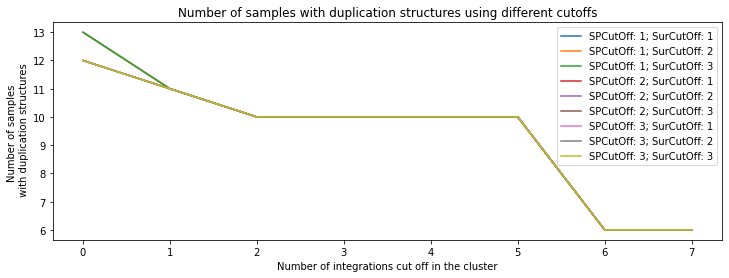

In [78]:
labels = []
plt.figure(figsize = [12,4])
for SPCutOff in range(1,4):
    for SurCutOff in range(1,4):
        y = cutOffListDf[(cutOffListDf['SPCutOff']==SPCutOff)&(cutOffListDf['SurCutOff']==SurCutOff)]['countSample']
        x = cutOffListDf[(cutOffListDf['SPCutOff']==SPCutOff)&(cutOffListDf['SurCutOff']==SurCutOff)]['lenClusterCutOff']
        plt.plot(x,y,label = f'SPCutOff: {SPCutOff}; SurCutOff: {SurCutOff}')
        labels.append(f'SPCutOff: {SPCutOff}; SurCutOff: {SurCutOff}')
        plt.legend(labels)
        plt.xlabel('Number of integrations cut off in the cluster')
        plt.ylabel('Number of samples \n with duplication structures')
        plt.title('Number of samples with duplication structures using different cutoffs')
        

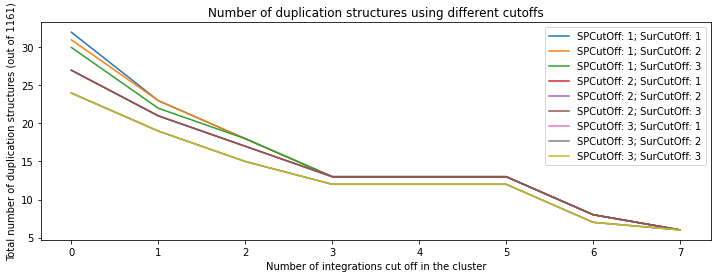

In [79]:
labels = []
plt.figure(figsize = [12,4])
for SPCutOff in range(1,4):
    for SurCutOff in range(1,4):
        y = cutOffListDf[(cutOffListDf['SPCutOff']==SPCutOff)&(cutOffListDf['SurCutOff']==SurCutOff)]['countDup']
        x = cutOffListDf[(cutOffListDf['SPCutOff']==SPCutOff)&(cutOffListDf['SurCutOff']==SurCutOff)]['lenClusterCutOff']
        plt.plot(x,y,label = f'SPCutOff: {SPCutOff}; SurCutOff: {SurCutOff}')
        labels.append(f'SPCutOff: {SPCutOff}; SurCutOff: {SurCutOff}')
        plt.legend(labels)
        plt.xlabel('Number of integrations cut off in the cluster')
        plt.ylabel('Total number of duplication structures (out of 1161)')
        plt.title('Number of duplication structures using different cutoffs')
        plt.savefig('CL_ins_num_dup.pdf')
        
        

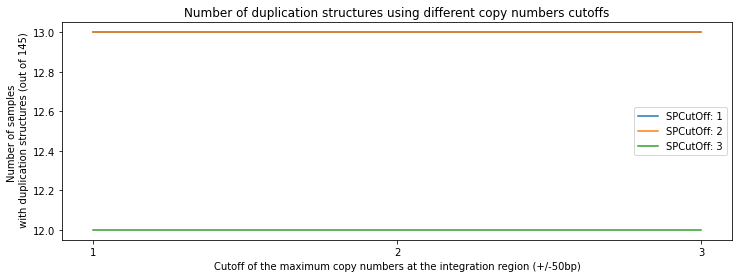

In [80]:
labels = []
plt.figure(figsize = [12,4])
for SPCutOff in range(1,4):
    y = cutOffListDf[(cutOffListDf['lenClusterCutOff']==3)&(cutOffListDf['SPCutOff']==SPCutOff) ]['countDup']
    x = cutOffListDf[(cutOffListDf['lenClusterCutOff']==3)&(cutOffListDf['SPCutOff']==SPCutOff)]['SurCutOff']
    plt.plot(x,y,label = f'SPCutOff: {SPCutOff}')
    labels.append(f'SPCutOff: {SPCutOff}')
    plt.legend(labels)
    plt.xlabel('Cutoff of the maximum copy numbers at the integration region (+/-50bp)')
    plt.ylabel('Number of samples \n with duplication structures (out of 145)')
    plt.title('Number of duplication structures using different copy numbers cutoffs')
    plt.xticks(range(1,4,1))



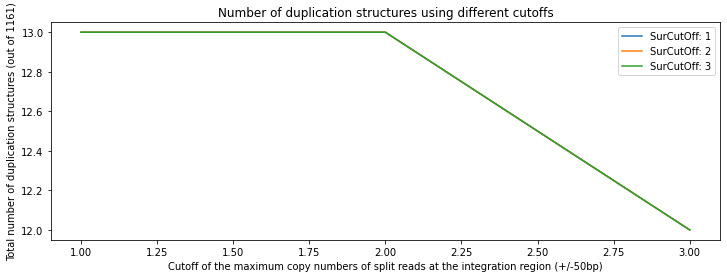

In [81]:
labels = []
plt.figure(figsize = [12,4])
for SurCutOff in range(1,4):
    y = cutOffListDf[(cutOffListDf['lenClusterCutOff']==3)&(cutOffListDf['SurCutOff']==SPCutOff) ]['countDup']
    x = cutOffListDf[(cutOffListDf['lenClusterCutOff']==3)&(cutOffListDf['SurCutOff']==SPCutOff)]['SPCutOff']
    plt.plot(x,y,label = f'SurCutOff: {SurCutOff}')
    labels.append(f'SurCutOff: {SurCutOff}')
    plt.legend(labels)
    plt.xlabel('Cutoff of the maximum copy numbers of split reads at the integration region (+/-50bp)')
    plt.ylabel('Total number of duplication structures (out of 1161)')
    plt.title('Number of duplication structures using different cutoffs')



In [82]:
len(DupCountDic)

18

In [83]:
len(clusteredSiteRes)

18

In [84]:
# #check exist of additional samples
# depth_path = '/home/wenjingu/remillsscr/HPV_fusion/HPV_nanopore_assembler/'
# for each in HPV_samples_df['Nanopore Sample ID']:
#     has_sample = False
#     files = os.listdir(depth_path)
#     for file in files:
#         if not file.startswith('_') and not file.startswith('.') and 'txt' in file:
#             if file.split('_')[0] in each or file.split('.')[0] in each:
#                 has_sample = True
#                 print(file,each)
#     if not has_sample:
#         print(each) # no need to add sample, it's UM_SCC_47


In [96]:
HPV_samples_df = annDf[(annDf['TCS ID'] != 'NO TCS') & (~annDf['INS type'].isna())].reset_index(drop = True)
HPV_samples_df.reset_index(drop=True)

,TCS ID,INS type,Nanopore Sample Name,Nanopore Sample ID,RNAseq ID,Total reads (QC- pass + fail),Primary reads,Secondary reads,Supplementary reads,Total mapped,Primary mapped,% primary mapped,HPV16 reads (Primary),Total HPV16 reads
0,81279,Type2,UM-SCC-47,864-LP-1,82552,2142523,1611843,418943,111737,2002179,1471499,91.292949,95,805
1,2655-CB-84,Type1,Tumor A (4840),2610-CB-3,NaN,499988,370111,97326,32551,496979,367102,99.187001,4,14
2,152-CB-96,Type2,PDX-294R,3816-CB,NCI - KX3N20,2382255,1710843,467130,204282,2210063,1538651,89.935254,39,899
3,2655-CB-93,Type2,UD-SCC-2,4745-CB-1,85971,2942240,1874688,601296,466256,2939457,1871905,99.851549,67,536
4,2655-CB-85,Type1,UM-SCC-104,3409-CB-1,82560,222816,148160,31140,43516,222406,147750,99.723272,0,2
5,2655-CB-89,Type2,VU-SCC-147,4745-CB-2,7572-EG-8,2035072,1396000,360328,278744,2033872,1394800,99.914040,362,1441
6,2655-CB-91,Type2,UPCI-SCC-152,4102-CB,7572-EG-5,8832341,6450564,1864768,517009,8820370,6438593,99.814419,2564,4925
7,2655-CB-92,Type2,UPCI-SCC-154,5219-CB-2,7572-EG-9,1326658,873077,230456,223125,1325757,872176,99.896802,0,13
8,2655-CB-90,Type2,UPCI-SCC-90,5219-CB-1,7572-EG-6,5032162,3731049,970744,330369,5027562,3726449,99.876710,4019,8853
9,2655-CB-88,Type2,UM-SCV-6,5219-CB-3,7572-EG-10,2341562,1268800,358400,714362,2339074,1266312,99.803909,149,664


In [87]:
 len(HPV_samples_df)

17

In [88]:
# #check junctionListDic
# LR_res = '/home/wenjingu/remillsscr/HPV_fusion/HPV_nanopore_assembler/all_sample_12_18_2023/'
# current_samples = []
# for file in os.listdir(LR_res):
#     if 'junctionListDic.pickle' in file:
#             current_samples.append(file.split('.')[0])
# current_samples = set(current_samples)


In [89]:
# missing_sample_juntionList = ['2352','3749_B','3744_B']

In [90]:
######generate dictionary of junction local depth
#extract depth Dictionary for each junction
def depth_dic(junctionListDic):
    depthDic = {}
    for read in junctionListDic:
        for info in junctionListDic[read]:
            i = 0
            for each in info['chro']:
                parent_node = each + ':' + str(info['junction'][i]) 
                junction = parent_node
                depth = info['depth'][i]
                if junction in depthDic:
                    depthDic[junction].append(depth)
                else:
                    depthDic[junction] = [depth]
                i += 1
    newDepthDic = {}
    for junction in depthDic:
        newDepthDic[junction] = max(depthDic[junction])
    return newDepthDic

In [93]:
def read_cov(chro,file):
    with open(file) as inputFile:
        inputFile.readline()
        rows = inputFile.read().rsplit('\n')
        for row in rows:
            if row.split('\t')[0] == chro:
                cov = float(row.split('\t')[6])
    return cov

In [97]:
#validation rate of different number in a cluster
LR_res = '/home/wenjingu/remillsscr/HPV_fusion/HPV_nanopore_assembler/all_sample_05_07_2025/'

depth_path = '/home/wenjingu/remillsscr/HPV_fusion/HPV_nanopore_assembler/'
validate_complex = []
validate_simple = []
for j in range(0,20):
    DupCountDic = defineDup(1, 2, j)
    i = 0
    compare_dic_dup = {}
    for sample in HPV_samples_df['TCS ID']:
        sample = str(sample)
        if DupCountDic[sample] != {}:
            compare_dic_dup[sample] = []
            for chro in DupCountDic[sample]:
                if DupCountDic[sample][chro] != []:
                    lr_sample_name = str(HPV_samples_df['Nanopore Sample Name'][i]).replace('(','').replace(')','').replace(' ','_')

    #                 if f'{sample_name[i]}.{chro}.junctionListDic.pickle' in os.listdir(LR_res):
                    with open(f'{LR_res}/{lr_sample_name}.{chro}.depth.junctionListDic.pickle','rb') as inputFile:
                        lr_dic = pickle.load(inputFile)
                        depthDic = depth_dic(lr_dic)
    #                     if sample_name[i] == 'UPCI:154' and chro == '9':
                        depthFile = f'{depth_path}/{lr_sample_name}.txt'
                        cov = read_cov(chro,depthFile)
                        for cluster in DupCountDic[sample][chro]:
                            is_valid = False
                            newCluster = []
                            for site in cluster:
                                for site2 in depthDic:
                                    if abs(int(site2.split(':')[1])- int(site.split(';')[0]))<=20:
                                        newCluster.append([site2,depthDic[site2]*2/cov,float(site.split(';')[1])])
                                        is_valid = True
                            if not is_valid:
                                print(sample,cluster)
                            if newCluster != []:
                                compare_dic_dup[sample].append(newCluster)

        i += 1
    i = 0            
    compare_dic_all = {}
    for sample in HPV_samples_df['TCS ID']:
        sample = str(sample)
        if clusteredSiteRes[sample] != {}:
            compare_dic_all[sample] = []
            for chro in clusteredSiteRes[sample]:
                if clusteredSiteRes[sample][chro] != []:
                    lr_sample_name = str(HPV_samples_df['Nanopore Sample Name'][i]).replace('(','').replace(')','').replace(' ','_')
    #                 if f'{sample_name[i]}.{chro}.junctionListDic.pickle' in os.listdir(LR_res):
                    with open(f'{LR_res}/{lr_sample_name}.{chro}.depth.junctionListDic.pickle','rb') as inputFile:
                        lr_dic = pickle.load(inputFile)
                        depthDic = depth_dic(lr_dic)
    #                     if sample_name[i] == 'UPCI:154' and chro == '9':
                            #print(depthDic)
                        
                        depthFile = f'{depth_path}/{lr_sample_name}.txt'
                        cov = read_cov(chro,depthFile)
                        for cluster in clusteredSiteRes[sample][chro]:
                            newCluster = []
                            for site in cluster:
                                for site2 in depthDic:
                                    if abs(int(site2.split(':')[1])- int(site.split(';')[0]))<=20:
                                         newCluster.append([site2,depthDic[site2]*2/cov,float(site.split(';')[1])])
                            if newCluster != []:
                                compare_dic_all[sample].append(newCluster)

        i += 1
    count1 = 0
    count2 = 0
    count3 = 0
    count4 = 0
    for sample in compare_dic_all:
        for cluster1 in compare_dic_all[sample]:
            isComplex = False
            for cluster2 in compare_dic_dup[sample]:
                for site1 in cluster1:
                    if site1 in cluster2:
                        isComplex = True
                        count1 += 1
                        break
                #print(site1)
            max_sp = 0
            max_loc = 0
            for site1 in cluster1:
                #print(site1)
                if float(site1[1]) > max_sp:
                    max_sp = np.round(float(site1[1]))
                if float(site1[2]) > max_loc:
                    max_loc = np.round(float(site1[2]))
            #print(cluster1)
            if isComplex:
                if max_loc >2 and max_sp >1 and len(cluster1) > j:
                    count2 += 1
            if not isComplex:
                count3 += 1
                if max_loc >2 and max_sp >1 and len(cluster1) > j:
                    pass
                else:
                    count4 += 1
                    
    if count1 > 0:            
        validate_complex.append(count2/count1)
    if count3 > 0:
        validate_simple.append(count4/count3)
        
        

        

In [99]:
len(validate_complex)

18

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

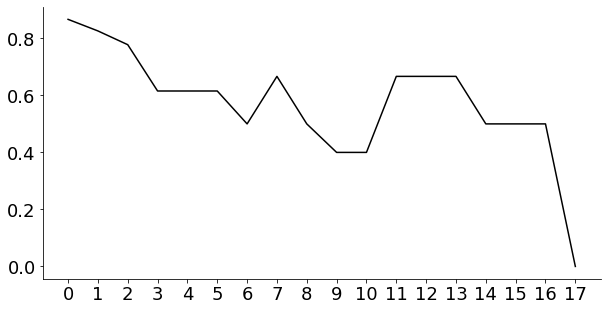

In [103]:
plt.figure(figsize = [10,5])
plt.plot(range(0,18),validate_complex,color = 'black')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(range(0,18,1),fontname='Arial',size = 18,weight = 'normal')
plt.yticks(fontname='Arial',size = 18,weight = 'normal')
plt.savefig('fig2_d.png',dpi = 600)

In [104]:
validate_simple

[1.0,
 0.75,
 0.8571428571428571,
 0.8846153846153846,
 0.9230769230769231,
 0.9615384615384616,
 0.9354838709677419,
 0.9696969696969697,
 0.9696969696969697,
 0.9411764705882353,
 1.0,
 1.0,
 1.0,
 1.0,
 0.972972972972973,
 0.972972972972973,
 0.972972972972973,
 0.9473684210526315,
 0.9743589743589743,
 0.9743589743589743]

In [105]:
geneDic = {}
gtfFileGenome = '/home/wenjingu/remillsscr/HPV_fusion/ref_hg19/Homo_sapiens.GRCh38.105.transcript.gtf'
with open(gtfFileGenome) as genome:
    rows = genome.read().rstrip().split('\n')
    for eachRow in rows:
        hasGeneName = False
        for each in eachRow.split('\t')[8].split(';'):
            if each.split('"')[0] == ' gene_name ':
                geneName = each.split('"')[1]
                hasGeneName = True
            if each.split('"')[0] == ' transcript_id ':
                trID = each.split('"')[1]
        if not hasGeneName:
            geneName = trID
        chro = eachRow.split('\t')[0]
        start = eachRow.split('\t')[3]
        end = eachRow.split('\t')[4]
        if trID not in geneDic:
            geneDic[trID] = [geneName,chro,start,end]
        else:
            print(eachRow)

In [106]:
DupCountDic = defineDup(1, 2, 1)
patient22List = []
for patient in DupCountDic:
    empty = True
    if DupCountDic[patient] != {}:
        for chro in DupCountDic[patient]:
            if DupCountDic[patient][chro] != []:
                empty = False
                for cluster in DupCountDic[patient][chro]:
                    countDup += 1
                    spList = []
                    surList = []
                    numList.append(len(cluster))
                    for each in cluster:
                        spList.append(each.split(';')[1])
                        surList.append(each.split(';')[2])
                    maxSP =max(spList)
                    maxSur = max(surList)
                    maxSpList.append(float(maxSP))
                    maxSurList.append(float(maxSur))
    if empty != True:
        print(patient)
        patient22List.append(patient)

2655-CB-91
2655-CB-89
2655-CB-90
2655-CB-84
2655-CB-88
2655-CB-92
2655-CB-93
6670-CB-92
6670-CB-86
81279
152-CB-96


In [107]:
DupCountDic

{'6670-CB-87': {'1': []},
 '6670-CB-88': {},
 '2655-CB-91': {'9': [['97813335;23.1714332025316;46.68219701681575',
    '97814224;0.0484758016789364;0.1454274050368092',
    '97833766;4.6536769611778945;9.598208732429407',
    '97857784;2.811596497378311;7.3683218551983325',
    '97860564;1.1634192402944736;3.8295883326359754',
    '97869989;1.1149434386155372;3.296354514167675',
    '97901339;1.1149434386155372;3.6841609275991662',
    '97902954;1.1634192402944736;1.5027498520470284',
    '97908821;2.9570239024151204;4.84758016789364',
    '97914603;56.4743089559609;137.67127676817938',
    '97940224;2.42379008394682;5.089959176288322',
    '97942608;210.82126150169438;455.13930196353385',
    '97942781;0.0484758016789364;140.43439746387875',
    '97952091;102.23546574087686;353.0977394293727']],
  '2': [],
  '6': [],
  '11': [],
  '8': [],
  '3': [['81785783;1.939032067157456;3.6841609275991662',
    '81992132;5.962523606509177;12.555232634844527',
    '82226566;2.8600722990572476;4.8

In [108]:
#integrations fell into duplication structures
path = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/sampleWithDuplications.05.07.25/TCSIntegrationList_dup_CL.csv'
with open(path,'w', encoding='UTF8', newline='') as output:
    writer = csv.writer(output)
    writer.writerow(['SampleID','SeqID','Chro','Ins','SPCov','hpvIns','Conf','numIns','GeneFallInto','GeneWithin50k'])
    for sample in DupCountDic:
        if 'Sample_' +str(sample) in all_dic:
            #print(sample)
            for chro in DupCountDic[sample]:
                for cluster in DupCountDic[sample][chro]:
                    numIns = len(cluster)
                    for each in cluster:
                        site = each.split(';')[0]
                        spCov = each.split(';')[1]
                        #record HPV ins
                        hpvInsList = ''
                        confList = ''
                        for contig in all_dic['Sample_' +str(sample)][chro+'.'+site]:
                            if contig[-1] != 'lowConfidence':
                                hpvInsList += str(contig[-1])+';'
                                confList += 'high'+';'
                            else:
                                hpvInsList += str(contig[-2])+';'
                                confList += 'low'+';'
                        #print(each)
                        geneList_1 = []
                        geneList_2 = []
                        for gene in geneDic:
                            if geneDic[gene][1] == chro and int( geneDic[gene][2])  <= int(site) and int( geneDic[gene][3]) >= int(site):
                                geneList_1.append(geneDic[gene][0])
                            if geneDic[gene][1] == chro and int( geneDic[gene][2]) - 50000 <= int(site) and int( geneDic[gene][3]) + 50000 >= int(site):
                                geneList_2.append(geneDic[gene][0])
                        writer.writerow([sample,f'Sample_{sample}',chro,site,spCov,hpvInsList,confList,numIns,";".join(set(geneList_1)),";".join(set(geneList_2))])
        else:
            for sampleID in patientInfo[sample]:
                if all_dic[sampleID] != {}:
                    for chro in DupCountDic[sample]:
                        for cluster in DupCountDic[sample][chro]:
                            numIns = len(cluster)
                            for each in cluster:
                                if chro + '.' + each.split(';')[0] in all_dic[sampleID]:
                                    site = each.split(';')[0]
                                    spCov = each.split(';')[1]
                                    #record HPV ins
                                    hpvInsList = ''
                                    confList = ''
                                    for contig in all_dic[sampleID][chro+'.'+site]:
                                        if contig[-1] != 'lowConfidence':
                                            hpvInsList += str(contig[-1])+';'
                                            confList += 'high'+';'
                                        else:
                                            hpvInsList += str(contig[-2])+';'
                                            confList += 'low'+';'
                                    geneList_1 = []
                                    geneList_2 = []
                                    for gene in geneDic:
                                        if geneDic[gene][1] == chro and int( geneDic[gene][2])  <= int(site) and int( geneDic[gene][3])>= int(site):
                                            geneList_1.append(geneDic[gene][0])


                                        if geneDic[gene][1] == chro and int( geneDic[gene][2])- 50000  <= int(site) and int( geneDic[gene][3])+ 50000 >= int(site):
                                            geneList_2.append(geneDic[gene][0])
                                    writer.writerow([sample,sampleID,chro,site,spCov,hpvInsList,confList,numIns,";".join(set(geneList_1)),";".join(set(geneList_2))])
            
                                    
                                    

In [109]:
sample22List = []
path = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/sampleWithDuplications.05.07.25/TCSIntegrationList_dup_CL.csv'
with open(path) as inputFile:
    inputFile.readline()
    rows = inputFile.read().rstrip().split('\n')
    for row in rows:
        sample = row.split(',')[1]
        
        sample22List.append(sample)
        sample22List = list(set(sample22List))



In [113]:
#check breakpoint in LR
LR_res = '/home/wenjingu/remillsscr/HPV_fusion/HPV_nanopore_assembler/all_sample_05_07_2025/'

i = 0
compare_dic_dup = {}
for sample in HPV_samples_df['TCS ID']:
    sample = str(sample)
    if DupCountDic[sample] != {}:
        compare_dic_dup[sample] = []
        for chro in DupCountDic[sample]:
            if DupCountDic[sample][chro] != []:
#                 if f'{sample_name[i]}.{chro}.junctionListDic.pickle' in os.listdir(LR_res):
                lr_sample_name = str(HPV_samples_df['Nanopore Sample Name'][i]).replace('(','').replace(')','').replace(' ','_')
                with open(f'{LR_res}/{lr_sample_name}.{chro}.depth.junctionListDic.pickle','rb') as inputFile:
                    lr_dic = pickle.load(inputFile)
                    depthDic = depth_dic(lr_dic)
#                     if sample_name[i] == 'UPCI:154' and chro == '9':
                        #print(depthDic)
                    depthFile = f'{depth_path}/{lr_sample_name}.txt'
                    cov = read_cov(chro,depthFile)
                    for cluster in DupCountDic[sample][chro]:
                        is_valid = False
                        newCluster = []
                        for site in cluster:
                            for site2 in depthDic:
                                if abs(int(site2.split(':')[1])- int(site.split(';')[0]))<=20:
                                    newCluster.append([site2,depthDic[site2]*2/cov,float(site.split(';')[1])])
                                    is_valid = True
                        if not is_valid:
                            print(sample,cluster)
                        if newCluster != []:
                            compare_dic_dup[sample].append(newCluster)
                    
    i += 1
i = 0            
compare_dic_all = {}
for sample in HPV_samples_df['TCS ID']:
    sample = str(sample)
    if clusteredSiteRes[sample] != {}:
        compare_dic_all[sample] = []
        for chro in clusteredSiteRes[sample]:
            if clusteredSiteRes[sample][chro] != []:
#                 if f'{sample_name[i]}.{chro}.junctionListDic.pickle' in os.listdir(LR_res):
                lr_sample_name = str(HPV_samples_df['Nanopore Sample Name'][i]).replace('(','').replace(')','').replace(' ','_')
                with open(f'{LR_res}/{lr_sample_name}.{chro}.depth.junctionListDic.pickle','rb') as inputFile:
                    lr_dic = pickle.load(inputFile)
                    depthDic = depth_dic(lr_dic)
#                     if sample_name[i] == 'UPCI:154' and chro == '9':
                        #print(depthDic)
                    depthFile = f'{depth_path}/{lr_sample_name}.txt'
                    cov = read_cov(chro,depthFile)
                    for cluster in clusteredSiteRes[sample][chro]:
                        newCluster = []
                        for site in cluster:
                            for site2 in depthDic:
                                if abs(int(site2.split(':')[1])- int(site.split(';')[0]))<=20:
                                     newCluster.append([site2,depthDic[site2]*2/cov,float(site.split(';')[1])])
                        if newCluster != []:
                            compare_dic_all[sample].append(newCluster)
                    
    i += 1
    

In [114]:
compare_dic_dup

{'81279': [[['3:189879024', np.float64(115.15811682103441), 4.247733445545312],
   ['3:189879690', np.float64(2.1484723287506418), 0.8752534333040052],
   ['3:189879676', np.float64(0.4296944657501284), 0.8752534333040052],
   ['3:189883773', np.float64(3.0078612602508987), 1.0466317279369572],
   ['3:189889702', np.float64(1.7187778630005135), 0.826288206266019],
   ['3:189895061', np.float64(113.43933895803389), 47.686010481618915]]],
 '2655-CB-84': [[['9:136906963',
    np.float64(7.81232707088515),
    8.880205772597206],
   ['9:136917997', np.float64(2.6041090236283835), 7.275037382215203],
   ['9:136917986', np.float64(5.208218047256767), 7.275037382215203]]],
 '152-CB-96': [[['9:95697333',
    np.float64(2.796567213745128),
    17.42591513616213],
   ['9:95697503', np.float64(0.699141803436282), 16.457808739708675]],
  [['3:125401493', np.float64(4.3660904466822394), 19.846181127295758],
   ['3:125401502', np.float64(5.6135448600200215), 19.846181127295758],
   ['3:125447480', n

In [115]:
DupCountDic

{'6670-CB-87': {'1': []},
 '6670-CB-88': {},
 '2655-CB-91': {'9': [['97813335;23.1714332025316;46.68219701681575',
    '97814224;0.0484758016789364;0.1454274050368092',
    '97833766;4.6536769611778945;9.598208732429407',
    '97857784;2.811596497378311;7.3683218551983325',
    '97860564;1.1634192402944736;3.8295883326359754',
    '97869989;1.1149434386155372;3.296354514167675',
    '97901339;1.1149434386155372;3.6841609275991662',
    '97902954;1.1634192402944736;1.5027498520470284',
    '97908821;2.9570239024151204;4.84758016789364',
    '97914603;56.4743089559609;137.67127676817938',
    '97940224;2.42379008394682;5.089959176288322',
    '97942608;210.82126150169438;455.13930196353385',
    '97942781;0.0484758016789364;140.43439746387875',
    '97952091;102.23546574087686;353.0977394293727']],
  '2': [],
  '6': [],
  '11': [],
  '8': [],
  '3': [['81785783;1.939032067157456;3.6841609275991662',
    '81992132;5.962523606509177;12.555232634844527',
    '82226566;2.8600722990572476;4.8

In [116]:
compare_dic_all

{'81279': [[['3:189879024', np.float64(115.15811682103441), 4.247733445545312],
   ['3:189879690', np.float64(2.1484723287506418), 0.8752534333040052],
   ['3:189879676', np.float64(0.4296944657501284), 0.8752534333040052],
   ['3:189883773', np.float64(3.0078612602508987), 1.0466317279369572],
   ['3:189889702', np.float64(1.7187778630005135), 0.826288206266019],
   ['3:189895061', np.float64(113.43933895803389), 47.686010481618915]]],
 '2655-CB-84': [[['9:136906963',
    np.float64(7.81232707088515),
    8.880205772597206],
   ['9:136917997', np.float64(2.6041090236283835), 7.275037382215203],
   ['9:136917986', np.float64(5.208218047256767), 7.275037382215203]]],
 '152-CB-96': [[['9:95697333',
    np.float64(2.796567213745128),
    17.42591513616213],
   ['9:95697503', np.float64(0.699141803436282), 16.457808739708675]],
  [['3:125401493', np.float64(4.3660904466822394), 19.846181127295758],
   ['3:125401502', np.float64(5.6135448600200215), 19.846181127295758],
   ['3:125447480', n

In [117]:
#combine with tissue samples

In [119]:
clusteredSiteRes

{'6670-CB-87': {'1': [['182207603;0.048854754271742074;0.09770950854348415']]},
 '6670-CB-88': {},
 '2655-CB-91': {'9': [['26645008;0.1454274050368092;0.1454274050368092'],
   ['116921587;0.0484758016789364;0.242379008394682'],
   ['97813335;23.1714332025316;46.68219701681575',
    '97814224;0.0484758016789364;0.1454274050368092',
    '97833766;4.6536769611778945;9.598208732429407',
    '97857784;2.811596497378311;7.3683218551983325',
    '97860564;1.1634192402944736;3.8295883326359754',
    '97869989;1.1149434386155372;3.296354514167675',
    '97901339;1.1149434386155372;3.6841609275991662',
    '97902954;1.1634192402944736;1.5027498520470284',
    '97908821;2.9570239024151204;4.84758016789364',
    '97914603;56.4743089559609;137.67127676817938',
    '97940224;2.42379008394682;5.089959176288322',
    '97942608;210.82126150169438;455.13930196353385',
    '97942781;0.0484758016789364;140.43439746387875',
    '97952091;102.23546574087686;353.0977394293727'],
   ['99956760;3.8295883326359

In [120]:
HPV_samples_df

,TCS ID,INS type,Nanopore Sample Name,Nanopore Sample ID,RNAseq ID,Total reads (QC- pass + fail),Primary reads,Secondary reads,Supplementary reads,Total mapped,Primary mapped,% primary mapped,HPV16 reads (Primary),Total HPV16 reads
0,81279,Type2,UM-SCC-47,864-LP-1,82552,2142523,1611843,418943,111737,2002179,1471499,91.292949,95,805
1,2655-CB-84,Type1,Tumor A (4840),2610-CB-3,NaN,499988,370111,97326,32551,496979,367102,99.187001,4,14
2,152-CB-96,Type2,PDX-294R,3816-CB,NCI - KX3N20,2382255,1710843,467130,204282,2210063,1538651,89.935254,39,899
3,2655-CB-93,Type2,UD-SCC-2,4745-CB-1,85971,2942240,1874688,601296,466256,2939457,1871905,99.851549,67,536
4,2655-CB-85,Type1,UM-SCC-104,3409-CB-1,82560,222816,148160,31140,43516,222406,147750,99.723272,0,2
5,2655-CB-89,Type2,VU-SCC-147,4745-CB-2,7572-EG-8,2035072,1396000,360328,278744,2033872,1394800,99.914040,362,1441
6,2655-CB-91,Type2,UPCI-SCC-152,4102-CB,7572-EG-5,8832341,6450564,1864768,517009,8820370,6438593,99.814419,2564,4925
7,2655-CB-92,Type2,UPCI-SCC-154,5219-CB-2,7572-EG-9,1326658,873077,230456,223125,1325757,872176,99.896802,0,13
8,2655-CB-90,Type2,UPCI-SCC-90,5219-CB-1,7572-EG-6,5032162,3731049,970744,330369,5027562,3726449,99.876710,4019,8853
9,2655-CB-88,Type2,UM-SCV-6,5219-CB-3,7572-EG-10,2341562,1268800,358400,714362,2339074,1266312,99.803909,149,664


1 8.0
1 24.0
1 1.0
1 4.0
1 3.0
1 13.0
1 4.0
1 2.0
1 1.0
1 0.0
1 0.0
1 1.0


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

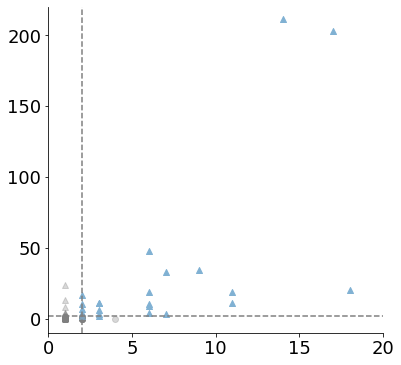

In [151]:
#cluster plot for TCS
count_complex = 0
count_simple = 0
plt.figure(figsize = [6,6])
for sample in HPV_samples_df['TCS ID']:
    sample = str(sample)
    for chro in clusteredSiteRes[sample]:
        for cluster1 in clusteredSiteRes[sample][chro]:
            isComplex = False
            for cluster2 in DupCountDic[sample][chro]:
                for site1 in cluster1:
                    if site1 in cluster2:
                        isComplex = True
                        break
            if isComplex:
                count_complex += 1
                max_sp = 0
                max_loc = 0
                for site1 in cluster1:
                    if float(site1.split(';')[1]) > max_sp:
                        max_sp = np.round(float(site1.split(';')[1]))
                    if float(site1.split(';')[2]) > max_loc:
                        max_loc = np.round(float(site1.split(';')[2]))
                
                if max_loc > 2:
                    plt.scatter(len(cluster1),max_sp,color = '#80b1d3',marker = '^')
                else:
                    
                    plt.scatter(len(cluster1),max_sp,color = '#80b1d3',marker = 'o')
                
                
            else:
                count_simple += 1
                max_sp = 0
                max_loc = 0
                for site1 in cluster1:
                    if float(site1.split(';')[1]) > max_sp:
                        max_sp = np.round(float(site1.split(';')[1]))
                    if float(site1.split(';')[2]) > max_loc:
                        max_loc = np.round(float(site1.split(';')[2]))
                #print(len(cluster1),max_sp)
                if max_loc > 2:
                    plt.scatter(len(cluster1),max_sp,color = 'tab:grey',alpha = 0.3,marker = '^')
                    print(len(cluster1),max_sp)
                else:
                    plt.scatter(len(cluster1),max_sp,color = 'tab:grey',alpha = 0.3,marker = 'o')
plt.vlines(x=2,ymin = -10,ymax = 220,color = 'tab:grey',linestyles='dashed')
plt.hlines(y=2,xmin = 0, xmax = 25,color = 'tab:grey',linestyles='dashed')
plt.xlim(0,20)
plt.ylim(-10,220)
plt.xticks(range(0,25,5),fontname='Arial',size = 18,weight = 'normal')
plt.yticks(range(0,220,50),fontname='Arial',size = 18,weight = 'normal')
#plt.ylabel('local copy number at HPV integration',fontname='Arial',size = 15)
#plt.xlabel('Number of integrations in each cluster',fontname='Arial',size = 15)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig('CL_sr.pdf',bbox_inches = 'tight')
                        

In [123]:
count_complex

23

In [124]:
count_simple

150

In [125]:
DupCountDic

{'6670-CB-87': {'1': []},
 '6670-CB-88': {},
 '2655-CB-91': {'9': [['97813335;23.1714332025316;46.68219701681575',
    '97814224;0.0484758016789364;0.1454274050368092',
    '97833766;4.6536769611778945;9.598208732429407',
    '97857784;2.811596497378311;7.3683218551983325',
    '97860564;1.1634192402944736;3.8295883326359754',
    '97869989;1.1149434386155372;3.296354514167675',
    '97901339;1.1149434386155372;3.6841609275991662',
    '97902954;1.1634192402944736;1.5027498520470284',
    '97908821;2.9570239024151204;4.84758016789364',
    '97914603;56.4743089559609;137.67127676817938',
    '97940224;2.42379008394682;5.089959176288322',
    '97942608;210.82126150169438;455.13930196353385',
    '97942781;0.0484758016789364;140.43439746387875',
    '97952091;102.23546574087686;353.0977394293727']],
  '2': [],
  '6': [],
  '11': [],
  '8': [],
  '3': [['81785783;1.939032067157456;3.6841609275991662',
    '81992132;5.962523606509177;12.555232634844527',
    '82226566;2.8600722990572476;4.8

In [126]:
compare_dic_all

{'81279': [[['3:189879024', np.float64(115.15811682103441), 4.247733445545312],
   ['3:189879690', np.float64(2.1484723287506418), 0.8752534333040052],
   ['3:189879676', np.float64(0.4296944657501284), 0.8752534333040052],
   ['3:189883773', np.float64(3.0078612602508987), 1.0466317279369572],
   ['3:189889702', np.float64(1.7187778630005135), 0.826288206266019],
   ['3:189895061', np.float64(113.43933895803389), 47.686010481618915]]],
 '2655-CB-84': [[['9:136906963',
    np.float64(7.81232707088515),
    8.880205772597206],
   ['9:136917997', np.float64(2.6041090236283835), 7.275037382215203],
   ['9:136917986', np.float64(5.208218047256767), 7.275037382215203]]],
 '152-CB-96': [[['9:95697333',
    np.float64(2.796567213745128),
    17.42591513616213],
   ['9:95697503', np.float64(0.699141803436282), 16.457808739708675]],
  [['3:125401493', np.float64(4.3660904466822394), 19.846181127295758],
   ['3:125401502', np.float64(5.6135448600200215), 19.846181127295758],
   ['3:125447480', n

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


[['3:189879024', np.float64(115.15811682103441), 4.247733445545312], ['3:189879690', np.float64(2.1484723287506418), 0.8752534333040052], ['3:189879676', np.float64(0.4296944657501284), 0.8752534333040052], ['3:189883773', np.float64(3.0078612602508987), 1.0466317279369572], ['3:189889702', np.float64(1.7187778630005135), 0.826288206266019], ['3:189895061', np.float64(113.43933895803389), 47.686010481618915]]
48.0 115.0 6
[['9:136906963', np.float64(7.81232707088515), 8.880205772597206], ['9:136917997', np.float64(2.6041090236283835), 7.275037382215203], ['9:136917986', np.float64(5.208218047256767), 7.275037382215203]]
9.0 8.0 3
[['9:95697333', np.float64(2.796567213745128), 17.42591513616213], ['9:95697503', np.float64(0.699141803436282), 16.457808739708675]]
17.0 3.0 2
[['3:125401493', np.float64(4.3660904466822394), 19.846181127295758], ['3:125401502', np.float64(5.6135448600200215), 19.846181127295758], ['3:125447480', np.float64(0.6237272066688914), 0.17084230525649144]]
20.0 6.0

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

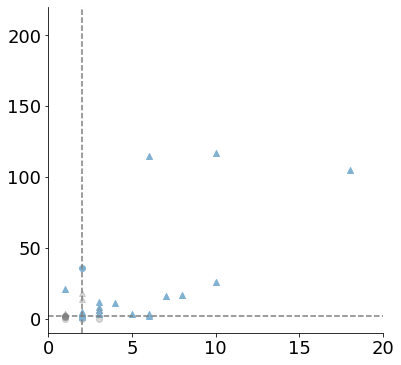

In [152]:
#cluster plot for LR
count = 0
count1 = 0
tcs_pos_lr_pos = 0
tcs_false_lr_false = 0
plt.figure(figsize = [6,6])
for sample in compare_dic_all:
    for cluster1 in compare_dic_all[sample]:
        isComplex = False
        for cluster2 in compare_dic_dup[sample]:
            for site1 in cluster1:
                if site1 in cluster2:
                    isComplex = True
                    break
            #print(site1)
        if isComplex:
                count += 1
                max_sp = 0
                max_loc = 0
                for site1 in cluster1:
                    if float(site1[1]) > max_sp:
                        max_sp = np.round(float(site1[1]))
                    if float(site1[2]) > max_loc:
                        max_loc = np.round(float(site1[2]))

                if max_loc > 2:
                    plt.scatter(len(cluster1),max_sp,color = '#80b1d3',marker = '^')
                else:

                    plt.scatter(len(cluster1),max_sp,color = '#80b1d3',marker = 'o')
                if max_loc >2 and max_sp >1 and len(cluster1) > 1:
                    tcs_pos_lr_pos  += 1
                    print(cluster1)
                    print(max_loc,max_sp,len(cluster1))
                    #plt.scatter(len(cluster1),max_sp,color = '#fb8072',marker = '^')
                

        else:
            count1 += 1
            max_sp = 0
            max_loc = 0
            for site1 in cluster1:
                if float(site1[1]) > max_sp:
                    max_sp = np.round(float(site1[1]))
                if float(site1[2]) > max_loc:
                    max_loc = np.round(float(site1[2]))
            #print(len(cluster1),max_sp)
            if max_loc > 2:
                plt.scatter(len(cluster1),max_sp,color = 'tab:grey',alpha = 0.3,marker = '^')
                #print(len(cluster1),max_sp)
            else:
                plt.scatter(len(cluster1),max_sp,color = 'tab:grey',alpha = 0.3,marker = 'o')
            if max_loc >2 and max_sp >1 and len(cluster1) > 1:
                
                print(cluster1)
                print(max_loc,max_sp,len(cluster1))
                #plt.scatter(len(cluster1),max_sp,color = '#fb8072',marker = '^')
            else:
                tcs_false_lr_false += 1
                

                
            
plt.vlines(x=2,ymin = -10,ymax = 220,color = 'tab:grey',linestyles='dashed')
plt.hlines(y=2,xmin = 0, xmax = 25,color = 'tab:grey',linestyles='dashed')
plt.xlim(0,20)
plt.ylim(-10,220)
plt.xticks(range(0,25,5),fontname='Arial',size = 18,weight = 'normal')
plt.yticks(range(0,220,50),fontname='Arial',size = 18,weight = 'normal')
#plt.ylabel('local copy number at HPV integration',fontname='Arial',size = 15)
#plt.xlabel('Number of integrations in each cluster',fontname='Arial',size = 15)
#plt.savefig('detectDuplication/CL_sr.pdf')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig('CL_lr.pdf',bbox_inches = 'tight')

In [128]:
tcs_pos_lr_pos

19

In [129]:
tcs_false_lr_false

12

In [130]:
print(count)

23


In [131]:
count1

16

In [136]:
tcs_pos_lr_pos/count

0.8260869565217391

In [133]:
tcs_false_lr_false/count1

0.75

In [140]:
HPV_samples_df['TCS ID']

0          81279
1     2655-CB-84
2      152-CB-96
3     2655-CB-93
4     2655-CB-85
5     2655-CB-89
6     2655-CB-91
7     2655-CB-92
8     2655-CB-90
9     2655-CB-88
10    6670-CB-90
11    6670-CB-88
12    6670-CB-93
13    6670-CB-91
14    6670-CB-86
15    6670-CB-87
16    6670-CB-92
Name: TCS ID, dtype: object

3 3.0 ['81785783;0.8733678702677045;1.829913632941857', '81992132;2.8280483418192337;7.8187218862061165', '82226566;1.3308462785031687;3.285526750054698']
1 1.0
6 19.0 ['36910796;5.905630360857812;15.096787471770321', '36936686;2.1210362563644254;10.937892851447918', '37161250;18.92297052246693;54.10721901039446', '37167442;11.353782313480158;26.325802946640806', '37175775;1.4556131171128408;3.784594104493386', '37176440;0.5822452468451363;0.9981347088773765']
17 203.0 ['97813335;19.42203787690562;40.549222548143426', '97833766;1.1644904936902727;3.41029358866437', '97857463;0.04158894620322402;0.20794473101612013', '97857784;1.372435224706393;4.741139867167539', '97891262;0.7070120854548084;1.4556131171128408', '97899374;0.24953367721934414;0.29112262342256817', '97901339;4.741139867167539;11.97761650652852', '97902954;1.9130915253483052;3.20234885764825', '97908821;1.996269417754753;3.784594104493386', '97914603;29.361796019476163;86.54659704890919', '97940224;1.9130915253483052;3.61

Text(0.5, 0, 'Number of integrations in each cluster')

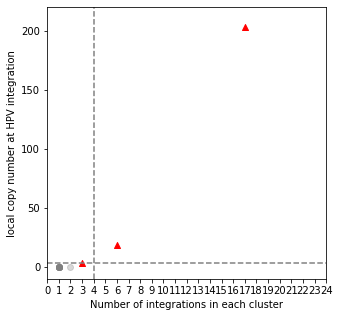

In [143]:
#cluster plot for TCS
plt.figure(figsize = [5,5])
sample = HPV_samples_df['TCS ID'][8]
for chro in clusteredSiteRes[sample]:
    for cluster1 in clusteredSiteRes[sample][chro]:
        isComplex = False
        for cluster2 in DupCountDic[sample][chro]:
            for site1 in cluster1:
                if site1 in cluster2:
                    isComplex = True
                    break
        if isComplex:
            max_sp = 0
            max_loc = 0
            for site1 in cluster1:
                if float(site1.split(';')[1]) > max_sp:
                    max_sp = np.round(float(site1.split(';')[1]))
                if float(site1.split(';')[2]) > max_loc:
                    max_loc = np.round(float(site1.split(';')[2]))

            if max_loc > 2:
                plt.scatter(len(cluster1),max_sp,color = 'red',marker = '^')
                print(len(cluster1),max_sp,cluster1)
            else:

                plt.scatter(len(cluster1),max_sp,color = 'red',marker = 'o')

        else:
            max_sp = 0
            max_loc = 0
            for site1 in cluster1:
                if float(site1.split(';')[1]) > max_sp:
                    max_sp = np.round(float(site1.split(';')[1]))
                if float(site1.split(';')[2]) > max_loc:
                    max_loc = np.round(float(site1.split(';')[2]))
            #print(len(cluster1),max_sp)
            if max_loc > 2:
                plt.scatter(len(cluster1),max_sp,color = 'grey',alpha = 0.3,marker = '^')
                print(len(cluster1),max_sp)
            else:
                plt.scatter(len(cluster1),max_sp,color = 'grey',alpha = 0.3,marker = 'o')
plt.vlines(x=4,ymin = -10,ymax = 220,color = 'grey',linestyles='dashed')
plt.hlines(y=3,xmin = 0, xmax = 25,color = 'grey',linestyles='dashed')
plt.xlim(0,24)
plt.ylim(-10,220)
plt.xticks(range(0,25))
plt.ylabel('local copy number at HPV integration')
plt.xlabel('Number of integrations in each cluster')
                        

14 211.0 ['97813335;23.1714332025316;46.68219701681575', '97814224;0.0484758016789364;0.1454274050368092', '97833766;4.6536769611778945;9.598208732429407', '97857784;2.811596497378311;7.3683218551983325', '97860564;1.1634192402944736;3.8295883326359754', '97869989;1.1149434386155372;3.296354514167675', '97901339;1.1149434386155372;3.6841609275991662', '97902954;1.1634192402944736;1.5027498520470284', '97908821;2.9570239024151204;4.84758016789364', '97914603;56.4743089559609;137.67127676817938', '97940224;2.42379008394682;5.089959176288322', '97942608;210.82126150169438;455.13930196353385', '97942781;0.0484758016789364;140.43439746387875', '97952091;102.23546574087686;353.0977394293727']
3 6.0 ['81785783;1.939032067157456;3.6841609275991662', '81992132;5.962523606509177;12.555232634844527', '82226566;2.8600722990572476;4.8960559695725765']


Text(0.5, 0, 'Number of integrations in each cluster')

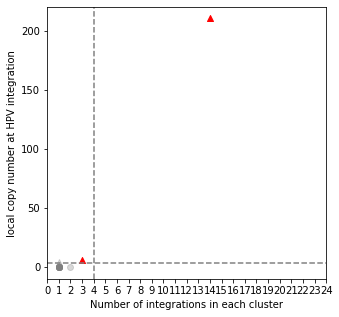

In [145]:
#cluster plot for TCS
plt.figure(figsize = [5,5])
sample = HPV_samples_df['TCS ID'][6]
for chro in clusteredSiteRes[sample]:
    for cluster1 in clusteredSiteRes[sample][chro]:
        isComplex = False
        for cluster2 in DupCountDic[sample][chro]:
            for site1 in cluster1:
                if site1 in cluster2:
                    isComplex = True
                    break
        if isComplex:
            max_sp = 0
            max_loc = 0
            for site1 in cluster1:
                if float(site1.split(';')[1]) > max_sp:
                    max_sp = np.round(float(site1.split(';')[1]))
                if float(site1.split(';')[2]) > max_loc:
                    max_loc = np.round(float(site1.split(';')[2]))

            if max_loc > 2:
                plt.scatter(len(cluster1),max_sp,color = 'red',marker = '^')
                print(len(cluster1),max_sp,cluster1)
            else:

                plt.scatter(len(cluster1),max_sp,color = 'red',marker = 'o')

        else:
            max_sp = 0
            max_loc = 0
            for site1 in cluster1:
                if float(site1.split(';')[1]) > max_sp:
                    max_sp = np.round(float(site1.split(';')[1]))
                if float(site1.split(';')[2]) > max_loc:
                    max_loc = np.round(float(site1.split(';')[2]))
            #print(len(cluster1),max_sp)
            if max_loc > 2:
                plt.scatter(len(cluster1),max_sp,color = 'grey',alpha = 0.3,marker = '^')
                
            else:
                plt.scatter(len(cluster1),max_sp,color = 'grey',alpha = 0.3,marker = 'o')
plt.vlines(x=4,ymin = -10,ymax = 220,color = 'grey',linestyles='dashed')
plt.hlines(y=3,xmin = 0, xmax = 25,color = 'grey',linestyles='dashed')
plt.xlim(0,24)
plt.ylim(-10,220)
plt.xticks(range(0,25))
plt.ylabel('local copy number at HPV integration')
plt.xlabel('Number of integrations in each cluster')
                        

In [ ]:
compare_dic_dup[sample]

['3:81785777', np.float64(0.23195398033030246), 0.8733678702677045]
['3:82226583', np.float64(0.23195398033030246), 1.3308462785031687]
['3:82226583', np.float64(0.23195398033030246), 1.3308462785031687]
7 16.0
['6:36910795', np.float64(5.399540701569073), 5.905630360857812]
['6:37176439', np.float64(1.6873564692403353), 0.5822452468451363]
26 195.0
26 195.0
['9:97813334', np.float64(40.76008955737987), 19.42203787690562]


Text(0.5, 0, 'Number of integrations in each cluster')

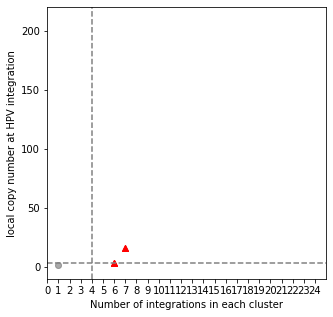

In [146]:
#cluster plot for TCS
plt.figure(figsize = [5,5])
sample = HPV_samples_df['TCS ID'][8]
for cluster1 in compare_dic_all[sample]:
    isComplex = False
    for cluster2 in compare_dic_dup[sample]:
        for site1 in cluster1:
            if site1 in cluster2:
                isComplex = True
                break
        
        if isComplex:
            print(site1)
            max_sp = 0
            max_loc = 0
            for site1 in cluster1:
                if float(site1[1]) > max_sp:
                    max_sp = np.round(float(site1[1]))
                if float(site1[2]) > max_loc:
                    max_loc = np.round(float(site1[2]))

            if max_loc > 2:
                plt.scatter(len(cluster1),max_sp,color = 'red',marker = '^')
            else:

                plt.scatter(len(cluster1),max_sp,color = 'red',marker = 'o')

        else:
            max_sp = 0
            max_loc = 0
            for site1 in cluster1:
                if float(site1[1]) > max_sp:
                    max_sp = np.round(float(site1[1]))
                if float(site1[2]) > max_loc:
                    max_loc = np.round(float(site1[2]))
            #print(len(cluster1),max_sp)
            if max_loc > 2:
                plt.scatter(len(cluster1),max_sp,color = 'grey',alpha = 0.3,marker = '^')
                print(len(cluster1),max_sp)
            else:
                plt.scatter(len(cluster1),max_sp,color = 'grey',alpha = 0.3,marker = 'o')

plt.vlines(x=4,ymin = -10,ymax = 220,color = 'grey',linestyles='dashed')
plt.hlines(y=3,xmin = 0, xmax = 25,color = 'grey',linestyles='dashed')
plt.xlim(0,25)
plt.ylim(-10,220)
plt.xticks(range(0,25))
plt.ylabel('local copy number at HPV integration')
plt.xlabel('Number of integrations in each cluster')






['9:97813334', np.float64(28.431063104913033), 23.1714332025316]
18 105.0 [['9:97813334', np.float64(28.431063104913033), 23.1714332025316], ['9:97814208', np.float64(0.24094121275350028), 0.0484758016789364], ['9:97833765', np.float64(2.4094121275350027), 4.6536769611778945], ['9:97857783', np.float64(1.2047060637675013), 2.811596497378311], ['9:97869995', np.float64(0.24094121275350028), 1.1149434386155372], ['9:97869988', np.float64(0.48188242550700056), 1.1149434386155372], ['9:97901338', np.float64(0.24094121275350028), 1.1149434386155372], ['9:97901330', np.float64(0.24094121275350028), 1.1149434386155372], ['9:97902954', np.float64(0.7228236382605009), 1.1634192402944736], ['9:97908816', np.float64(0.7228236382605009), 2.9570239024151204], ['9:97908822', np.float64(0.24094121275350028), 2.9570239024151204], ['9:97914602', np.float64(25.78070976462453), 56.4743089559609], ['9:97940223', np.float64(0.9637648510140011), 2.42379008394682], ['9:97942607', np.float64(100.2315445054561

Text(0.5, 0, 'Number of integrations in each cluster')

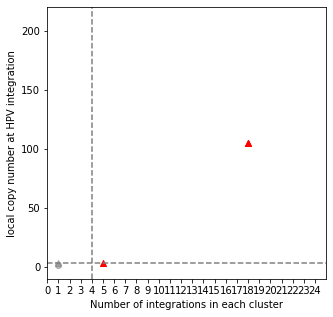

In [147]:
#cluster plot for TCS
plt.figure(figsize = [5,5])
sample = HPV_samples_df['TCS ID'][6]
for cluster1 in compare_dic_all[sample]:
    isComplex = False
    for cluster2 in compare_dic_dup[sample]:
        for site1 in cluster1:
            if site1 in cluster2:
                isComplex = True
                break
        
        if isComplex:
            print(site1)
            max_sp = 0
            max_loc = 0
            for site1 in cluster1:
                if float(site1[1]) > max_sp:
                    max_sp = np.round(float(site1[1]))
                if float(site1[2]) > max_loc:
                    max_loc = np.round(float(site1[2]))

            if max_loc > 2:
                plt.scatter(len(cluster1),max_sp,color = 'red',marker = '^')
                print(len(cluster1),max_sp,cluster1)
            else:

                plt.scatter(len(cluster1),max_sp,color = 'red',marker = 'o')

        else:
            max_sp = 0
            max_loc = 0
            for site1 in cluster1:
                if float(site1[1]) > max_sp:
                    max_sp = np.round(float(site1[1]))
                if float(site1[2]) > max_loc:
                    max_loc = np.round(float(site1[2]))
            #print(len(cluster1),max_sp)
            if max_loc > 2:
                plt.scatter(len(cluster1),max_sp,color = 'grey',alpha = 0.3,marker = '^')
                #print(len(cluster1),max_sp)
            else:
                plt.scatter(len(cluster1),max_sp,color = 'grey',alpha = 0.3,marker = 'o')

plt.vlines(x=4,ymin = -10,ymax = 220,color = 'grey',linestyles='dashed')
plt.hlines(y=3,xmin = 0, xmax = 25,color = 'grey',linestyles='dashed')
plt.xlim(0,25)
plt.ylim(-10,220)
plt.xticks(range(0,25))
plt.ylabel('local copy number at HPV integration')
plt.xlabel('Number of integrations in each cluster')






In [150]:
with open('clusteredSiteRes.05.07.25','wb') as f:
    pickle.dump(clusteredSiteRes,f)

In [ ]:
# #integrations fell into duplication structures,change to bed format
# path = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/sampleWithDuplications.05.05.22/TCSIntegrationList_dup.bed'
# with open(path,'w') as output:
#     for sample in DupCountDic:
#         if 'Sample_' +str(sample) in all_dic:
#             #print(sample)
#             for chro in DupCountDic[sample]:
#                 for cluster in DupCountDic[sample][chro]:
                    
#                     for each in cluster:
#                         site = each.split(';')[0]
#                         output.write(f'chr{chro}\t{site}\t{site}\tSample_{sample}\n')
#         else:
#             for sampleID in patientInfo[sample]:
#                 if all_dic[sampleID] != {}:
#                     for chro in DupCountDic[sample]:
#                         for cluster in DupCountDic[sample][chro]:
#                             for each in cluster:
#                                 if chro + '.' + each.split(';')[0] in all_dic[sampleID]:
#                                     site = each.split(';')[0]
#                                     output.write(f'chr{chro}\t{site}\t{site}\t{sampleID}\n')
            
                                    
                                    

In [ ]:
# #hg38 genedic
# geneDic_38 = {}
# gtfFileGenome = '/home/wenjingu/remillsscr/HPV_fusion/ref_hg19/Homo_sapiens.GRCh38.105.transcript.gtf'
# with open(gtfFileGenome) as genome:
#     rows = genome.read().rstrip().split('\n')
#     for eachRow in rows:
#         if eachRow[0] != '#':
#             geneName = ''
#             trID = ''
#             for each in eachRow.split('\t')[8].split('; '):
# #                 print(each)
# #                 print(each.split(' ')[0])
                
#                 if each.split(' ')[0] == 'gene_name':
#                     geneName = each.split('"')[1]
#                 if each.split(' ')[0] == 'transcript_id':
#                     trID = each.split('"')[1]
# #             print(geneName)
# #             print(trID)
#             chro = eachRow.split('\t')[0]
#             start = eachRow.split('\t')[3]
#             end = eachRow.split('\t')[4]
#             if trID not in geneDic_38:
#                 if geneName != '':
#                     geneDic_38[trID] = [geneName,chro,start,end]
#             else:
#                 print(eachRow)

In [ ]:
# for each in geneDic_38:
#     if 'NWD2' in geneDic_38[each][0]:
#         print(each,geneDic_38[each])

In [ ]:
# #conver to hg38 and rewrite
# path = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/sampleWithDuplications.05.05.22/TCSIntegrationList_dup.bed'
# outputPath = '/home/wenjingu/remillsscr/HPV_fusion/duplicationStructures/sampleWithDuplications.05.05.22/TCSIntegrationList_dup_hg38.csv'
# sample22List = []
# with open(outputPath,'w', encoding='UTF8', newline='') as output:
#     with open(path) as inputFile:
        
#         writer = csv.writer(output)
#         writer.writerow(['SampleID','Chro','Ins','GeneFallInto','GeneWithin50k','GeneWithin50_100k','GeneWithin100_150k'])
#         rows = inputFile.read().rstrip().split('\n')
#         for row in rows:
#             chro = row.split('\t')[0].replace('chr','')
#             site = row.split('\t')[1]
#             sample = row.split('\t')[3]
#             geneList_1 = []
#             geneList_2 = []
#             geneList_3 = []
#             geneList_4 = []
#             sample22List.append(sample)
#             for gene in geneDic_38:
#                 if geneDic_38[gene][1] == chro and int( geneDic_38[gene][2])  <= int(site) and int( geneDic_38[gene][3]) >= int(site):
#                     geneList_1.append(geneDic_38[gene][0])
#                 if geneDic_38[gene][1] == chro and int( geneDic_38[gene][2]) - 50000 <= int(site) and int( geneDic_38[gene][3]) + 50000 >= int(site):
#                     geneList_2.append(geneDic_38[gene][0])
#                 if geneDic_38[gene][1] == chro and int( geneDic_38[gene][2]) - 100000 <= int(site) and int( geneDic_38[gene][2]) - 50000 > int(site):
#                     geneList_3.append(geneDic_38[gene][0])
#                 if geneDic_38[gene][1] == chro and int( geneDic_38[gene][3]) + 100000 >= int(site) and int( geneDic_38[gene][3]) + 50000 < int(site):
#                     geneList_3.append(geneDic_38[gene][0])
#                 if geneDic_38[gene][1] == chro and int( geneDic_38[gene][2]) - 150000 <= int(site) and int( geneDic_38[gene][2]) - 100000 > int(site):
#                     geneList_4.append(geneDic_38[gene][0])
#                 if geneDic_38[gene][1] == chro and int( geneDic_38[gene][3]) + 150000 >= int(site) and int( geneDic_38[gene][3]) + 100000 < int(site):
#                     geneList_4.append(geneDic_38[gene][0])
#             writer.writerow([sample,chro,site,";".join(set(geneList_1)),";".join(set(geneList_2)),";".join(set(geneList_3)),";".join(set(geneList_4))])
            
            
            


